# ANÁLISIS COMPLETO PRONACIÓN-SUPINACIÓN — MDS-UPDRS 3.6
## Pipeline: Extracción → Inferencial → Discriminabilidad

**Estructura del pipeline:**
1. Extracción de features (motor de pronación-supinación v2, para todos los scores)
2. Consolidación del dataset con etiquetas de score y sujeto
3. Análisis descriptivo por score
4. Análisis inferencial (Kruskal-Wallis + tamaños de efecto)
5. Análisis de discriminabilidad (LDA + LOSO + AUC/ROC)
6. Exportación de resultados

**Diseño del estudio:**
- Score 0: 23 personas sanas (15 × 6 pruebas + 8 × 4 pruebas = 122 pruebas)
- Scores 1–4: 3 sujetos simulando cada nivel, 10 pruebas c/u (30 pruebas por score)
- Manos: derecha e izquierda (archivos separados por nombre)
- Tarea: Pronación-Supinación MDS-UPDRS ítem 3.6

**Diferencias clínicas vs Finger Tapping:**
- Señal de detección: `gx` (ωx rotacional) **directo**, no el ángulo integrado
- GYRO_LOWCUT = 0.1 Hz (movimiento más lento)
- No se calculan ITI, hesitaciones ni decremento (no aplican a pronación-supinación)
- Amplitud = diferencia pico pronación − pico supinación en ωx
- Cadencia calculada desde picos de pronación reales

**Convención de nombres de archivo esperada:**
```
score0/GA_01_right_01.json  → Score 0, sujeto GA_01, mano derecha, prueba 1
score1/P02_left_05.json     → Score 1, sujeto P02, mano izquierda, prueba 5
```

---
## CELDA 1 — Imports y configuración

In [ ]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
============================================================================
"""

import json
import os
import re
import warnings
from datetime import datetime
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.stats import kruskal, mannwhitneyu, spearmanr

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report,
    matthews_corrcoef
 )
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar rutas aquí
# ─────────────────────────────────────────────
class Config:
    # Raíz del dataset: debe contener subcarpetas score0/, score1/, ..., score4/
    RUTA_DATOS  = "./PRONATION_SUPINATION"   # <── AJUSTAR
    RUTA_SALIDA = "./resultados_pronosupina_completo"

    # ── Señal ──────────────────────────────────────────────────────────
    FS = 100           # Hz objetivo
    FS_TOLERANCE = 0.20

    # ── Filtros (pronación es más lenta → lowcut más bajo que tapping) ──
    GYRO_LOWCUT  = 0.1   # Hz  ← clave: 0.1 en lugar de 0.5 del tapping
    GYRO_HIGHCUT = 10.0  # Hz
    ACCEL_CUTOFF = 5.0   # Hz

    # ── Detección de ciclos ─────────────────────────────────────────────
    # Parámetros originales del notebook Prono-Supina v2
    PICO_PROMINENCE_FACTOR  = 0.15
    PICO_HEIGHT_FACTOR_POS  = 0.15
    PICO_HEIGHT_FACTOR_NEG  = 0.15
    PICO_MIN_DISTANCE       = 15   # muestras (más largo que tapping)
    PICO_WIDTH              = 5
    N_CICLOS_ESPERADOS      = 10
    USAR_TOP_N              = True

    # ── Validación ──────────────────────────────────────────────────────
    CICLOS_MIN_VALIDOS = 10   # ← 10 para pronación (vs 6 en tapping)
    DURACION_MINIMA    = 2.0  # segundos

    # ── Scores ──────────────────────────────────────────────────────────
    SCORES = [0, 1, 2, 3, 4]

    # ── Features para análisis ──────────────────────────────────────────
    # Sin ITI, sin hesitaciones, sin decremento (no aplican a pronación-supinación)
    FEATURES_ANALISIS = [
        'frecuencia', 'cadencia', 'intervalo_medio',
        'amplitud_media', 'amplitud_cv', 'amplitud_max',
        'amplitud_angular_media', 'rango_angular_total',
        'velocidad_pico_media', 'velocidad_pico_max',
        'regularidad',
        'compensacion_lateral',
        'jerk_rms', 'jerk_rms_angular',
        'rms_acc_lateral', 'energia_relativa_x',
        'rango_wx', 'rango_wy', 'rango_wz',
    ]

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
SCORE_LABELS = {0:'Score 0\n(Sano)', 1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4'}

print("✅ Configuración cargada")
print(f"   Ruta datos  : {Config.RUTA_DATOS}")
print(f"   Ruta salida : {Config.RUTA_SALIDA}")
print(f"   GYRO_LOWCUT : {Config.GYRO_LOWCUT} Hz  (pronación-supinación)")
print(f"   Features    : {len(Config.FEATURES_ANALISIS)} (sin ITI/hesitaciones/decremento)")

✅ Configuración cargada
   Ruta datos  : ./PRONATION_SUPINATION
   Ruta salida : ./resultados_pronosupina_completo
   GYRO_LOWCUT : 0.1 Hz  (pronación-supinación)
   Features    : 19 (sin ITI/hesitaciones/decremento)


---
## CELDA 2 — Motor de procesamiento de señal (pronación-supinación v2)

In [21]:
"""
============================================================================
MOTOR DE PROCESAMIENTO IMU → FEATURES  —  PRONACIÓN-SUPINACIÓN v2

Diferencias respecto a Finger Tapping:
  • Detección sobre gx (ωx) DIRECTO, no sobre el ángulo integrado
  • GYRO_LOWCUT = 0.1 Hz
  • Umbral fijo PICO_HEIGHT_FACTOR (no adaptativo multi-factor)
  • Rescate selectivo: solo repara el tipo deficiente (pos o neg)
  • Top-N aplicado DESPUÉS de alternancia
  • Cadencia desde picos_pos reales (no desde tiempos_medio)
  • Sin cálculo de ITI, hesitaciones ni decremento
  • angulo_x siempre integrado de gx (no del eje dominante)
============================================================================
"""

# ── Filtros ───────────────────────────────────────────────────────────────

def butter_bandpass(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def butter_lowpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='low')
    return filtfilt(b, a, data)

# ── Remuestreo ────────────────────────────────────────────────────────────

def eliminar_duplicados_tiempo(time, signals_dict):
    _, idx = np.unique(time, return_index=True)
    idx = np.sort(idx)
    return time[idx], {k: v[idx] for k, v in signals_dict.items()}

def remuestrear_uniforme(time, signals_dict, fs_target):
    time, signals_dict = eliminar_duplicados_tiempo(time, signals_dict)
    if len(time) < 4:
        return None, None
    n = int((time[-1] - time[0]) * fs_target) + 1
    if n < 4:
        return None, None
    t_uni = np.linspace(time[0], time[-1], n)
    return t_uni, {
        k: interp1d(time, v, kind='cubic', fill_value='extrapolate')(t_uni)
        for k, v in signals_dict.items()
    }

# ── Eje dominante ─────────────────────────────────────────────────────────

def detectar_eje_dominante_gyro(gx, gy, gz):
    return max({'gx': np.var(gx), 'gy': np.var(gy), 'gz': np.var(gz)},
               key=lambda k: {'gx': np.var(gx), 'gy': np.var(gy), 'gz': np.var(gz)}[k])

def detectar_eje_dominante_accel(ax, ay, az):
    return max({'ax': np.var(ax), 'ay': np.var(ay), 'az': np.var(az)},
               key=lambda k: {'ax': np.var(ax), 'ay': np.var(ay), 'az': np.var(az)}[k])

# ── Detección de ciclos ───────────────────────────────────────────────────

def seleccionar_top_n_picos(picos_pos, picos_neg, gx_signal, n):
    """[FIX 9] Top-N aplicado DESPUÉS de alternancia."""
    if len(picos_pos) > n:
        idx = np.argsort(np.abs(gx_signal[picos_pos]))[::-1][:n]
        picos_pos = np.sort(picos_pos[idx])
    if len(picos_neg) > n:
        idx = np.argsort(np.abs(gx_signal[picos_neg]))[::-1][:n]
        picos_neg = np.sort(picos_neg[idx])
    return picos_pos, picos_neg

def detectar_ciclos(gx_signal, time_signal, cfg):
    """
    Detección de ciclos de pronación-supinación sobre ωx (gx).
    Orden: Estrategia 1 → Rescate selectivo → Alternancia → Top-N → Emparejamiento
    """
    rango    = np.max(gx_signal) - np.min(gx_signal)
    prom_min = rango * cfg.PICO_PROMINENCE_FACTOR

    # ── Estrategia 1: detección principal ────────────────────────────────
    picos_pos, _ = find_peaks(
        gx_signal,
        prominence=prom_min,
        height=np.max(gx_signal) * cfg.PICO_HEIGHT_FACTOR_POS,
        distance=cfg.PICO_MIN_DISTANCE,
        width=cfg.PICO_WIDTH,
    )
    picos_neg, _ = find_peaks(
        -gx_signal,
        prominence=prom_min,
        # [FIX 11] np.abs → robusto si señal está toda en un lado
        height=np.abs(np.min(gx_signal)) * cfg.PICO_HEIGHT_FACTOR_NEG,
        distance=cfg.PICO_MIN_DISTANCE,
        width=cfg.PICO_WIDTH,
    )

    # ── [FIX 10] Rescate selectivo: SOLO el tipo deficiente ──────────────
    f = 0.5
    if len(picos_pos) < 3:
        p2, _ = find_peaks(
            gx_signal,
            height=np.max(gx_signal) * cfg.PICO_HEIGHT_FACTOR_POS * f,
            prominence=rango * cfg.PICO_PROMINENCE_FACTOR * f,
            distance=cfg.PICO_MIN_DISTANCE,
        )
        if len(p2) > len(picos_pos):
            picos_pos = p2

    if len(picos_neg) < 3:
        n2, _ = find_peaks(
            -gx_signal,
            height=np.abs(np.min(gx_signal)) * cfg.PICO_HEIGHT_FACTOR_NEG * f,
            prominence=rango * cfg.PICO_PROMINENCE_FACTOR * f,
            distance=cfg.PICO_MIN_DISTANCE,
        )
        if len(n2) > len(picos_neg):
            picos_neg = n2

    # ── Alternancia: conservar mayor amplitud absoluta ────────────────────
    todos = sorted(
        [('pos', int(p), gx_signal[p]) for p in picos_pos] +
        [('neg', int(p), gx_signal[p]) for p in picos_neg],
        key=lambda x: x[1],
    )
    fp, fn = [], []
    ut = ui = uv = None
    for tipo, idx, val in todos:
        if ut is None:
            ut, ui, uv = tipo, idx, val
        elif tipo != ut:
            (fp if ut == 'pos' else fn).append(ui)
            ut, ui, uv = tipo, idx, val
        else:
            if abs(val) > abs(uv):
                ui, uv = idx, val
    if ut is not None:
        (fp if ut == 'pos' else fn).append(ui)

    picos_pos = np.array(fp, dtype=int) if fp else np.array([], dtype=int)
    picos_neg = np.array(fn, dtype=int) if fn else np.array([], dtype=int)

    # ── [FIX 9] Top-N DESPUÉS de alternancia ─────────────────────────────
    if cfg.USAR_TOP_N and cfg.N_CICLOS_ESPERADOS > 0:
        picos_pos, picos_neg = seleccionar_top_n_picos(
            picos_pos, picos_neg, gx_signal, cfg.N_CICLOS_ESPERADOS
        )

    # ── Emparejamiento greedy bidireccional ───────────────────────────────
    ciclos = emparejar_ciclos(picos_pos, picos_neg, time_signal, gx_signal)
    return picos_pos, picos_neg, len(ciclos), ciclos


def emparejar_ciclos(picos_pos, picos_neg, time, gx):
    """Greedy bidireccional por mínima distancia temporal."""
    if len(picos_pos) == 0 or len(picos_neg) == 0:
        return []
    pares = sorted(
        [(abs(time[n] - time[p]), int(p), int(n))
         for p in picos_pos for n in picos_neg],
        key=lambda x: x[0],
    )
    ciclos, up, un = [], set(), set()
    for dist, p, n in pares:
        if p not in up and n not in un:
            up.add(p); un.add(n)
            ciclos.append({
                'pos_idx':      p,
                'neg_idx':      n,
                'amplitud':     abs(gx[p] - gx[n]),   # diferencia pron - supina
                'tiempo_medio': (time[p] + time[n]) / 2.0,
                'duracion_ciclo': abs(time[n] - time[p]),
            })
    ciclos.sort(key=lambda x: x['tiempo_medio'])
    return ciclos

# ── Pipeline principal: JSON → features dict ─────────────────────────────

def procesar_json_a_features(json_path, cfg):
    """
    Carga un archivo JSON de IMU y retorna un dict con todas las features
    de pronación-supinación. Retorna None si el archivo es inválido.
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
    except Exception as e:
        print(f"  ✗ Error cargando {os.path.basename(json_path)}: {e}")
        return None

    # Soporta lista directa o dict con 'imuData'/'data'
    if isinstance(raw, list):
        imu_data = raw
    elif isinstance(raw, dict):
        imu_data = raw.get('imuData', raw.get('data', []))
    else:
        return None

    if len(imu_data) < 50:
        return None

    # Usar el primer dispositivo encontrado
    dispositivos = {}
    for d in imu_data:
        did = d.get('deviceId', 'device0')
        dispositivos.setdefault(did, []).append(d)
    datos = list(dispositivos.values())[0]

    # ── Extraer señales ───────────────────────────────────────────────────
    time = np.array([d['timestamp'] for d in datos])
    time = (time - time[0]) / 1000.0

    sig_raw = {
        'gx': np.array([d.get('gyroscope', {}).get('x', 0) for d in datos]),
        'gy': np.array([d.get('gyroscope', {}).get('y', 0) for d in datos]),
        'gz': np.array([d.get('gyroscope', {}).get('z', 0) for d in datos]),
        'ax': np.array([d.get('accelerometer', {}).get('x', 0) for d in datos]),
        'ay': np.array([d.get('accelerometer', {}).get('y', 0) for d in datos]),
        'az': np.array([d.get('accelerometer', {}).get('z', 0) for d in datos]),
    }

    # ── FS real ──────────────────────────────────────────────────────────
    dt_real = np.median(np.diff(time))
    fs_real = 1.0 / dt_real if dt_real > 0 else cfg.FS

    # ── Remuestreo uniforme ───────────────────────────────────────────────
    time, sig = remuestrear_uniforme(time, sig_raw, fs_real)
    if time is None:
        return None
    dt = 1.0 / fs_real

    # ── Filtros ───────────────────────────────────────────────────────────
    gx_f = butter_bandpass(sig['gx'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    gy_f = butter_bandpass(sig['gy'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    gz_f = butter_bandpass(sig['gz'], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    ax_f = butter_lowpass(sig['ax'], cfg.ACCEL_CUTOFF, fs_real)
    ay_f = butter_lowpass(sig['ay'], cfg.ACCEL_CUTOFF, fs_real)
    az_f = butter_lowpass(sig['az'], cfg.ACCEL_CUTOFF, fs_real)

    # ── angulo_x: integración trapezoidal de gx (siempre ωx) ─────────────
    angulo_x = np.insert(np.cumsum(0.5 * (gx_f[:-1] + gx_f[1:])) * dt, 0, 0.0)

    # ── Ejes dominantes ───────────────────────────────────────────────────
    eje_gyro_dom  = detectar_eje_dominante_gyro(gx_f, gy_f, gz_f)
    eje_accel_dom = detectar_eje_dominante_accel(ax_f, ay_f, az_f)

    gyro_map  = {'gx': gx_f, 'gy': gy_f, 'gz': gz_f}
    accel_map = {'ax': ax_f, 'ay': ay_f, 'az': az_f}

    # ── Detección de ciclos sobre gx DIRECTO ─────────────────────────────
    picos_pos, picos_neg, n_ciclos, ciclos = detectar_ciclos(gx_f, time, cfg)

    # ── Features de ciclos ────────────────────────────────────────────────
    amplitudes      = [c['amplitud'] for c in ciclos]
    tiempos_ciclo   = [c['tiempo_medio'] for c in ciclos]
    amp_angulares   = [abs(angulo_x[c['pos_idx']] - angulo_x[c['neg_idx']]) for c in ciclos]
    vel_pico        = ([abs(gx_f[p]) for p in picos_pos] +
                       [abs(gx_f[p]) for p in picos_neg])

    # ── FFT (sobre gx) ────────────────────────────────────────────────────
    N  = len(gx_f)
    yf = fft(gx_f)
    xf = fftfreq(N, 1.0 / fs_real)[:N // 2]
    pw = np.abs(yf[:N // 2])
    freq_dom = float(xf[np.argmax(pw[1:]) + 1]) if len(pw) > 1 else 0.0

    # ── Regularidad de amplitud ───────────────────────────────────────────
    regularidad = 0.0
    if amplitudes and np.mean(amplitudes) > 0:
        cv = np.std(amplitudes) / np.mean(amplitudes)
        regularidad = max(0.0, min(100.0, (1 - cv) * 100))

    # ── [FIX 12] Cadencia desde picos_pos reales (pronación) ─────────────
    cadencia = intervalo_real = 0.0
    if len(picos_pos) > 1:
        diffs = np.diff(time[picos_pos])
        intervalo_real = float(np.mean(diffs))
        if intervalo_real > 0:
            cadencia = 1.0 / intervalo_real

    # ── Compensación lateral: ejes gyro NO dominantes ─────────────────────
    lat_gyro = [v for k, v in gyro_map.items() if k != eje_gyro_dom]
    comp_lat = (float(np.std(np.concatenate([e.reshape(-1) for e in lat_gyro])))
                if lat_gyro else 0.0)

    # ── RMS acc lateral: ejes accel NO dominantes ─────────────────────────
    lat_accel = [v for k, v in accel_map.items() if k != eje_accel_dom]
    rms_acc_lat = (float(np.sqrt(np.mean(np.sum([e**2 for e in lat_accel], axis=0))))
                   if lat_accel else 0.0)

    # ── Jerk (sobre ejes dominantes) ──────────────────────────────────────
    jerk_ang = np.gradient(gx_f, dt)               # jerk angular sobre gx
    jerk_lin = np.gradient(accel_map[eje_accel_dom], dt)  # jerk lineal eje dom

    # ── Energía relativa del eje gyro dominante ───────────────────────────
    e_dom   = float(np.mean(gyro_map[eje_gyro_dom] ** 2))
    e_total = float(np.mean(gx_f**2) + np.mean(gy_f**2) + np.mean(gz_f**2))
    e_rel   = e_dom / e_total if e_total > 0 else 0.0

    # ── Validación ────────────────────────────────────────────────────────
    duracion = float(time[-1] - time[0])
    valido   = (n_ciclos >= cfg.CICLOS_MIN_VALIDOS) and (duracion >= cfg.DURACION_MINIMA)

    return {
        # Metadatos
        'archivo':  os.path.basename(json_path),
        'valido':   valido,
        'n_ciclos': int(n_ciclos),
        'duracion': duracion,
        'fs_real':  float(fs_real),
        'eje_gyro_dom':  eje_gyro_dom,
        'eje_accel_dom': eje_accel_dom,
        # Features
        'frecuencia':             freq_dom,
        'cadencia':               float(cadencia),
        'intervalo_medio':        intervalo_real,
        'amplitud_media':         float(np.mean(amplitudes)) if amplitudes else 0.0,
        'amplitud_std':           float(np.std(amplitudes))  if amplitudes else 0.0,
        'amplitud_cv':            float(np.std(amplitudes)/np.mean(amplitudes))
                                  if amplitudes and np.mean(amplitudes)>0 else 0.0,
        'amplitud_max':           float(np.max(amplitudes))  if amplitudes else 0.0,
        'amplitud_min':           float(np.min(amplitudes))  if amplitudes else 0.0,
        'amplitud_angular_media': float(np.mean(amp_angulares)) if amp_angulares else 0.0,
        'amplitud_angular_std':   float(np.std(amp_angulares))  if amp_angulares else 0.0,
        'amplitud_angular_max':   float(np.max(amp_angulares))  if amp_angulares else 0.0,
        'rango_angular_total':    float(np.ptp(angulo_x)),
        'velocidad_pico_media':   float(np.mean(vel_pico)) if vel_pico else 0.0,
        'velocidad_pico_max':     float(np.max(vel_pico))  if vel_pico else 0.0,
        'velocidad_pico_std':     float(np.std(vel_pico))  if vel_pico else 0.0,
        'regularidad':            float(regularidad),
        'compensacion_lateral':   float(comp_lat),
        'rango_wx':               float(np.ptp(gx_f)),
        'rango_wy':               float(np.ptp(gy_f)),
        'rango_wz':               float(np.ptp(gz_f)),
        'jerk_rms':               float(np.sqrt(np.mean(jerk_lin**2))),
        'jerk_rms_angular':       float(np.sqrt(np.mean(jerk_ang**2))),
        'rms_acc_lateral':        float(rms_acc_lat),
        'energia_relativa_x':     float(e_rel),
    }

print("✅ Motor de extracción pronación-supinación listo")

✅ Motor de extracción pronación-supinación listo


---
## CELDA 3 — Carga y consolidación del dataset completo

In [22]:
"""
============================================================================
CARGA DE TODOS LOS ARCHIVOS JSON Y CONSTRUCCIÓN DEL DATAFRAME MAESTRO
============================================================================
"""

def extraer_metadatos(json_data):
    """Extrae sujeto del JSON cargado."""
    # Score ya no lo sacamos de aquí para priorizar la carpeta
    
    # Sujeto
    sujeto = json_data.get('patient', {}).get('id', 'unknown')
    return sujeto


def cargar_dataset_completo(cfg):
    filas = []
    resumen = []
    
    for score in cfg.SCORES:
        carpeta = os.path.join(cfg.RUTA_DATOS, f'Score {score}')
        if not os.path.isdir(carpeta):
            print(f"  ⚠️  Carpeta no encontrada: {carpeta}")
            continue

        archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith('.json')])
        ok = invalido = error = 0
        
        for fname in archivos:
            fpath = os.path.join(carpeta, fname)
            
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    raw = json.load(f)
            except Exception as e:
                error += 1
                continue
                
            sujeto = extraer_metadatos(raw)
            
            imu_data = raw.get('imuData', raw.get('data', []))
            if not imu_data:
                error += 1
                continue
                
            # Agrupar por deviceId para procesar cada mano
            dispositivos = {}
            for d in imu_data:
                did = d.get('deviceId', 'unknown')
                dispositivos.setdefault(did, []).append(d)
                
            for did, datos in dispositivos.items():
                if 'RIGHT' in did.upper() or 'DERECHA' in did.upper():
                    mano = 'right'
                elif 'LEFT' in did.upper() or 'IZQUIERDA' in did.upper():
                    mano = 'left'
                else:
                    mano = 'unknown'
                    
                # Crear archivo temporal con los datos de esta mano
                # para no alterar procesar_json_a_features
                temp_path = f"temp_imu_{sujeto}_{mano}.json"
                try:
                    with open(temp_path, 'w', encoding='utf-8') as f:
                        json.dump(datos, f)
                    
                    feats = procesar_json_a_features(temp_path, cfg)
                finally:
                    if os.path.exists(temp_path):
                        os.remove(temp_path)
                
                if feats is None:
                    error += 1
                    continue
                    
                feats['score']    = int(score)
                feats['sujeto']   = sujeto
                feats['mano']     = mano
                feats['n_prueba'] = 1  # Ajustar si se cruzan pruebas del mismo sujeto
                
                if feats['valido']:
                    filas.append(feats)
                    ok += 1
                else:
                    invalido += 1
                
        resumen.append({'score': score, 'total': len(archivos),
                        'válidos': ok, 'inválidos': invalido, 'errores': error})
        print(f"  Score {score}: {len(archivos)} archivos → {ok} válidos, {invalido} inválidos, {error} errores")
        
    return pd.DataFrame(filas), pd.DataFrame(resumen)


print("🔄 Cargando dataset...")
df_master, df_resumen_carga = cargar_dataset_completo(Config)

print(f"\n{'='*60}")
print(f"DATASET CARGADO: {len(df_master)} pruebas válidas")
print(f"{'='*60}")
if not df_resumen_carga.empty:
    print(df_resumen_carga.to_string(index=False))
    print(f"\nScores presentes : {sorted(df_master['score'].unique())}")
    print(f"Sujetos únicos   : {df_master['sujeto'].nunique()}")
    print(f"Manos            : {df_master['mano'].unique().tolist()}")
    print(f"Features         : {len(Config.FEATURES_ANALISIS)}")

    print("\nPruebas por score × mano:")
    print(df_master.groupby(['score','mano']).size().unstack(fill_value=0).to_string())

    csv_path = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro.csv"
    df_master.to_csv(csv_path, index=False)
    print(f"\n💾 Dataset guardado: {csv_path}")
else:
    print("⚠️ No se cargaron datos válidos.")

🔄 Cargando dataset...
  Score 0: 102 archivos → 149 válidos, 55 inválidos, 0 errores
  Score 1: 30 archivos → 59 válidos, 1 inválidos, 0 errores
  Score 2: 31 archivos → 61 válidos, 1 inválidos, 0 errores
  Score 3: 31 archivos → 62 válidos, 0 inválidos, 0 errores
  Score 4: 31 archivos → 60 válidos, 2 inválidos, 0 errores

DATASET CARGADO: 391 pruebas válidas
 score  total  válidos  inválidos  errores
     0    102      149         55        0
     1     30       59          1        0
     2     31       61          1        0
     3     31       62          0        0
     4     31       60          2        0

Scores presentes : [0, 1, 2, 3, 4]
Sujetos únicos   : 21
Manos            : ['right', 'left']
Features         : 19

Pruebas por score × mano:
mano   left  right
score             
0        75     74
1        29     30
2        31     30
3        31     31
4        30     30

💾 Dataset guardado: ./resultados_pronosupina_completo/tablas/dataset_maestro.csv


---
## CELDA 4 — Análisis descriptivo por score

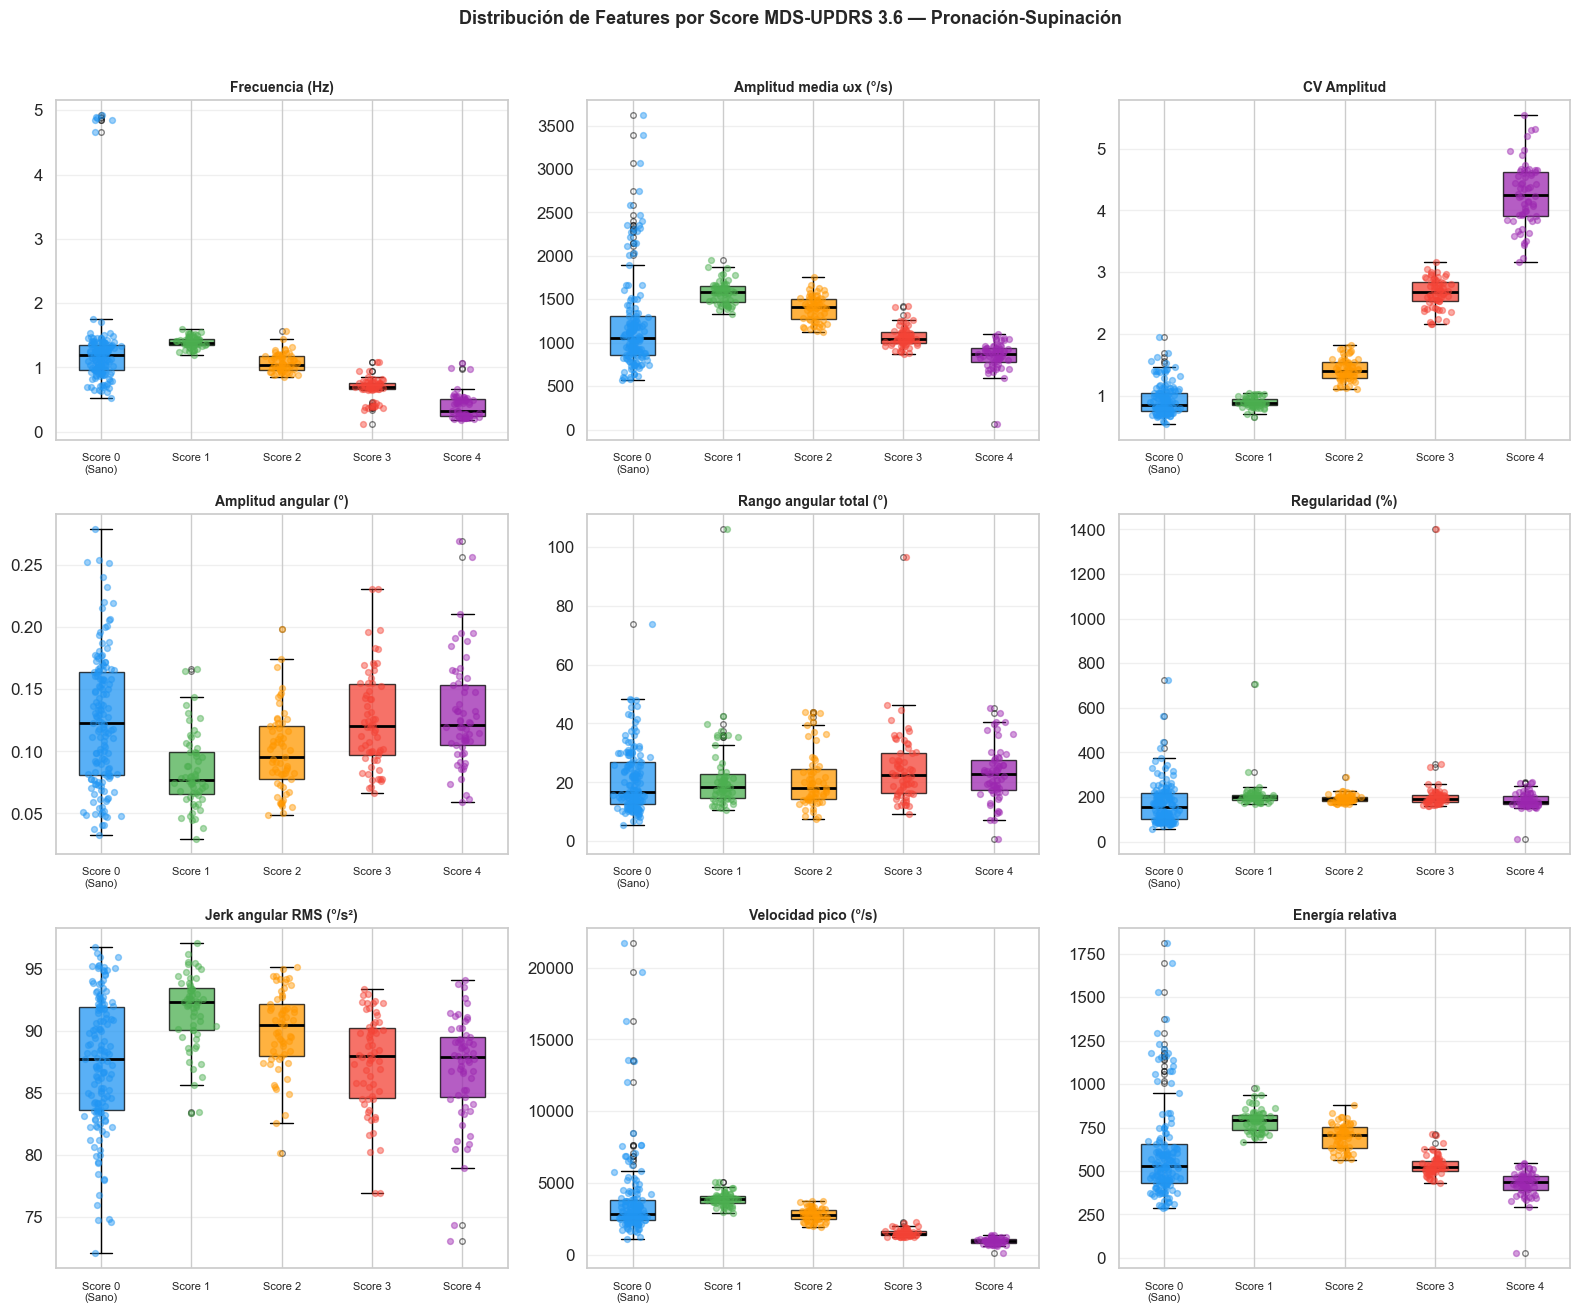

✅ Boxplots guardados

Medianas por score — features principales:
score                    0         1         2         3        4
feature                                                          
amplitud_cv          0.123     0.077     0.095     0.120    0.122
amplitud_media    1053.063  1587.014  1412.576  1040.642  874.598
frecuencia           1.190     1.385     1.040     0.695    0.324
intervalo_medio      0.842     0.885     1.407     2.681    4.244
jerk_rms_angular  2854.335  3882.543  2785.737  1466.405  959.464
regularidad         87.691    92.319    90.454    87.957   87.846


In [23]:
"""
============================================================================
ANÁLISIS DESCRIPTIVO
Features elegidas para visualizar: las más relevantes clínicamente
para pronación-supinación (sin ITI/hesitaciones/decremento)
============================================================================
"""

FEATURES_PLOT = [
    'frecuencia', 'amplitud_media', 'intervalo_medio', 'amplitud_cv',
    'amplitud_angular_media', 'rango_angular_total', 'regularidad',
    'jerk_rms_angular', 'velocidad_pico_media', 'energia_relativa_x'
]

LABELS_PLOT = [
    'Frecuencia (Hz)', 'Amplitud media ωx (°/s)', 'CV Amplitud',
    'Amplitud angular (°)', 'Rango angular total (°)', 'Regularidad (%)',
    'Jerk angular RMS (°/s²)', 'Velocidad pico (°/s)', 'Energía relativa'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(FEATURES_PLOT, LABELS_PLOT)):
    ax = axes[i]
    data_por_score = [df_master[df_master['score']==s][feat].dropna().values
                      for s in Config.SCORES]

    bp = ax.boxplot(data_por_score,
                    labels=[SCORE_LABELS[s] for s in Config.SCORES],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))

    for patch, score in zip(bp['boxes'], Config.SCORES):
        patch.set_facecolor(SCORE_COLORS[score])
        patch.set_alpha(0.75)

    for j, (datos, score) in enumerate(zip(data_por_score, Config.SCORES)):
        x = np.random.normal(j+1, 0.07, size=len(datos))
        ax.scatter(x, datos, alpha=0.45, s=18, color=SCORE_COLORS[score], zorder=5)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Features por Score MDS-UPDRS 3.6 — Pronación-Supinación',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/descriptivo_boxplots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplots guardados")

# ── Tabla de estadísticos por score ──
rows = []
for score in Config.SCORES:
    sub = df_master[df_master['score']==score]
    for feat in Config.FEATURES_ANALISIS:
        v = sub[feat].dropna()
        rows.append({
            'score': score, 'feature': feat, 'n': len(v),
            'mediana': np.median(v) if len(v)>0 else np.nan,
            'IQR':     np.percentile(v,75)-np.percentile(v,25) if len(v)>0 else np.nan,
            'media':   np.mean(v) if len(v)>0 else np.nan,
            'std':     np.std(v)  if len(v)>0 else np.nan,
        })

df_descriptivo = pd.DataFrame(rows)
df_descriptivo.to_csv(f"{Config.RUTA_SALIDA}/tablas/descriptivo_por_score.csv", index=False)

print("\nMedianas por score — features principales:")
pivot = df_descriptivo[df_descriptivo['feature'].isin(
    ['frecuencia','amplitud_media','intervalo_medio','amplitud_cv','regularidad','jerk_rms_angular']
)].pivot_table(index='feature', columns='score', values='mediana', aggfunc='first').round(3)
print(pivot.to_string())

---
## CELDA 4B — Análisis visual por estadio

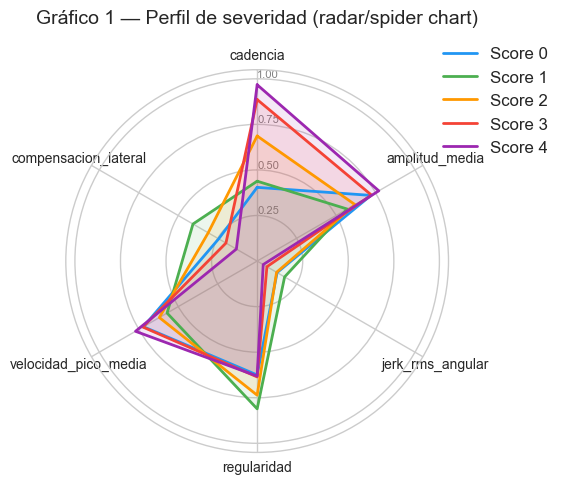

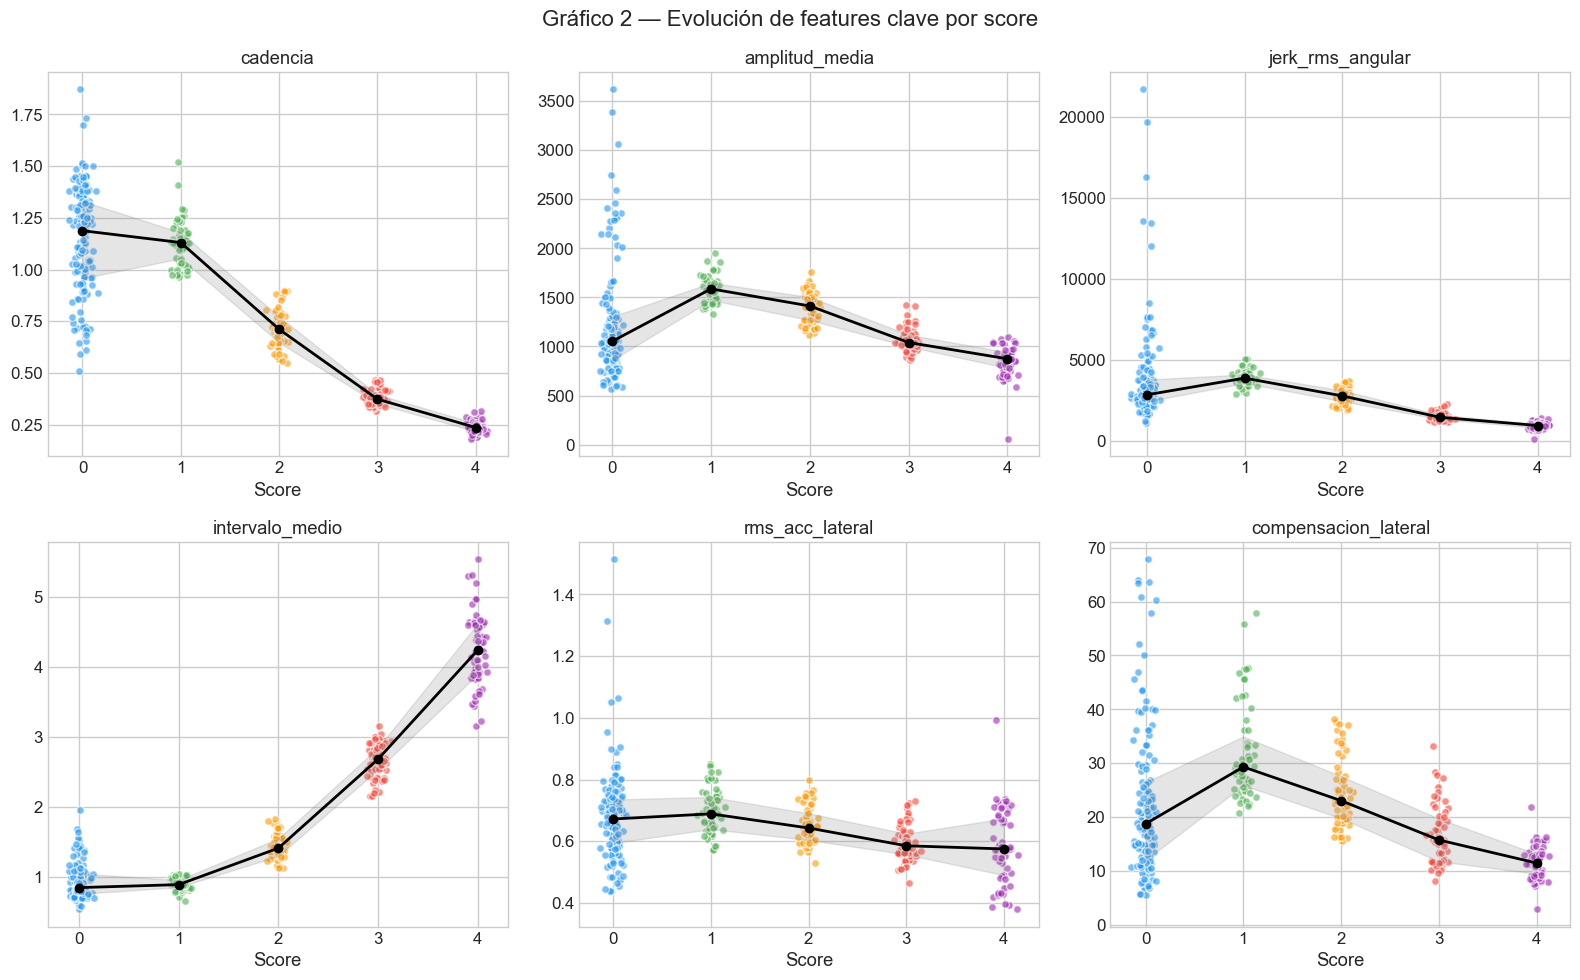

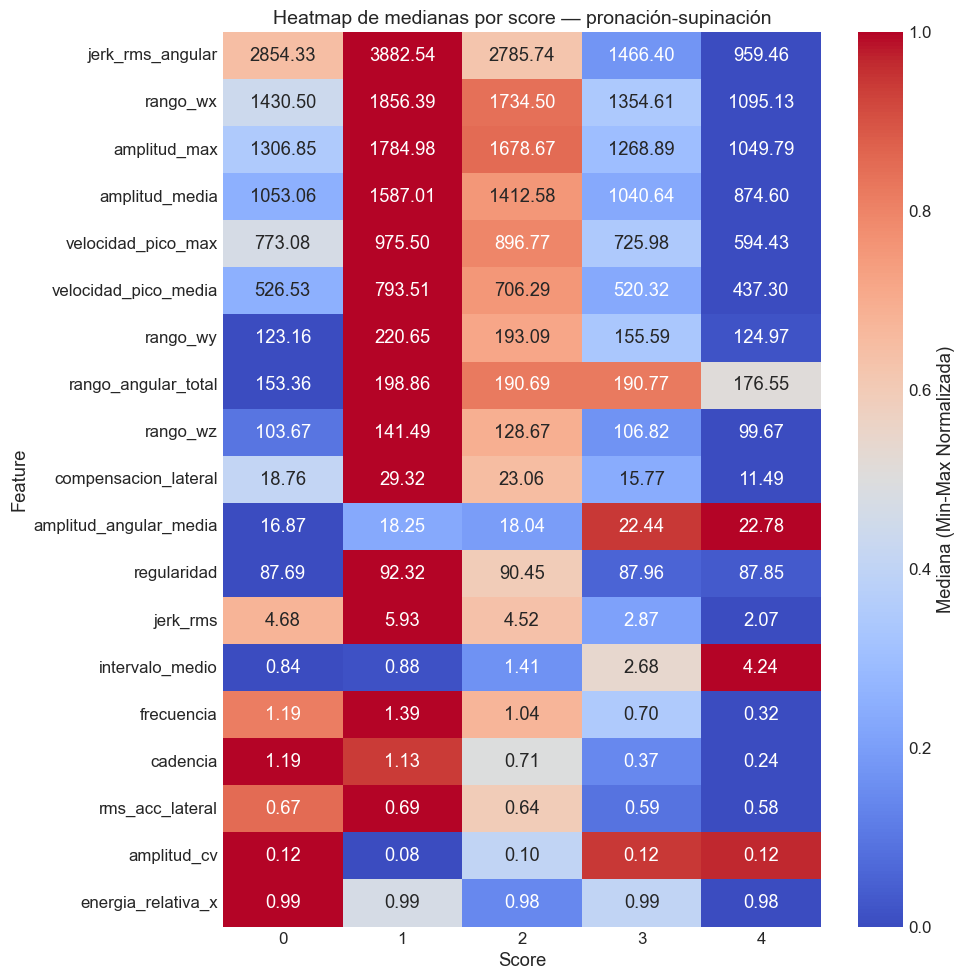

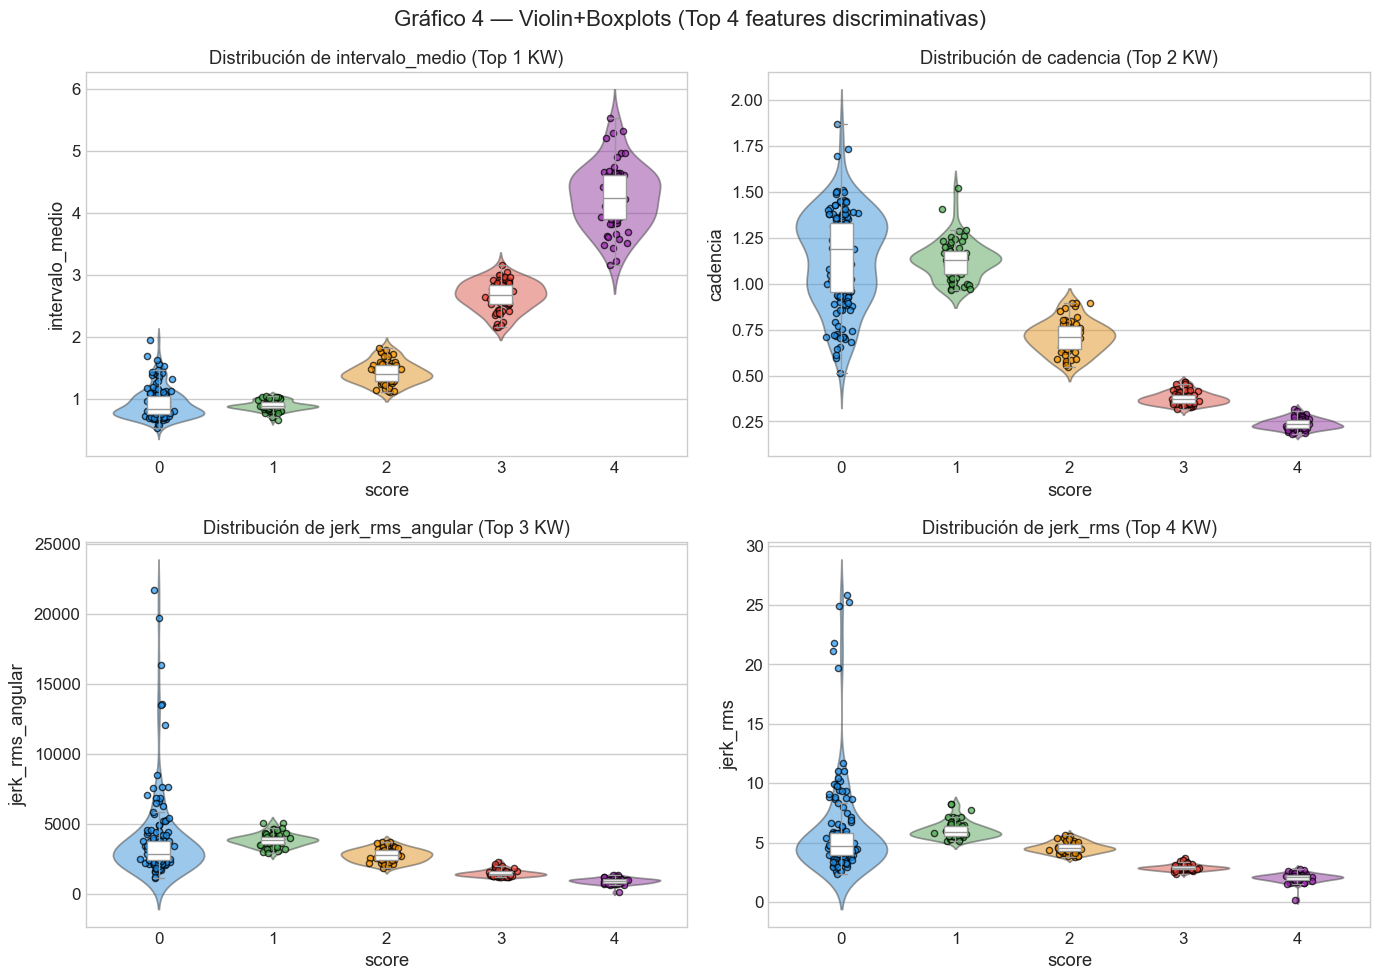

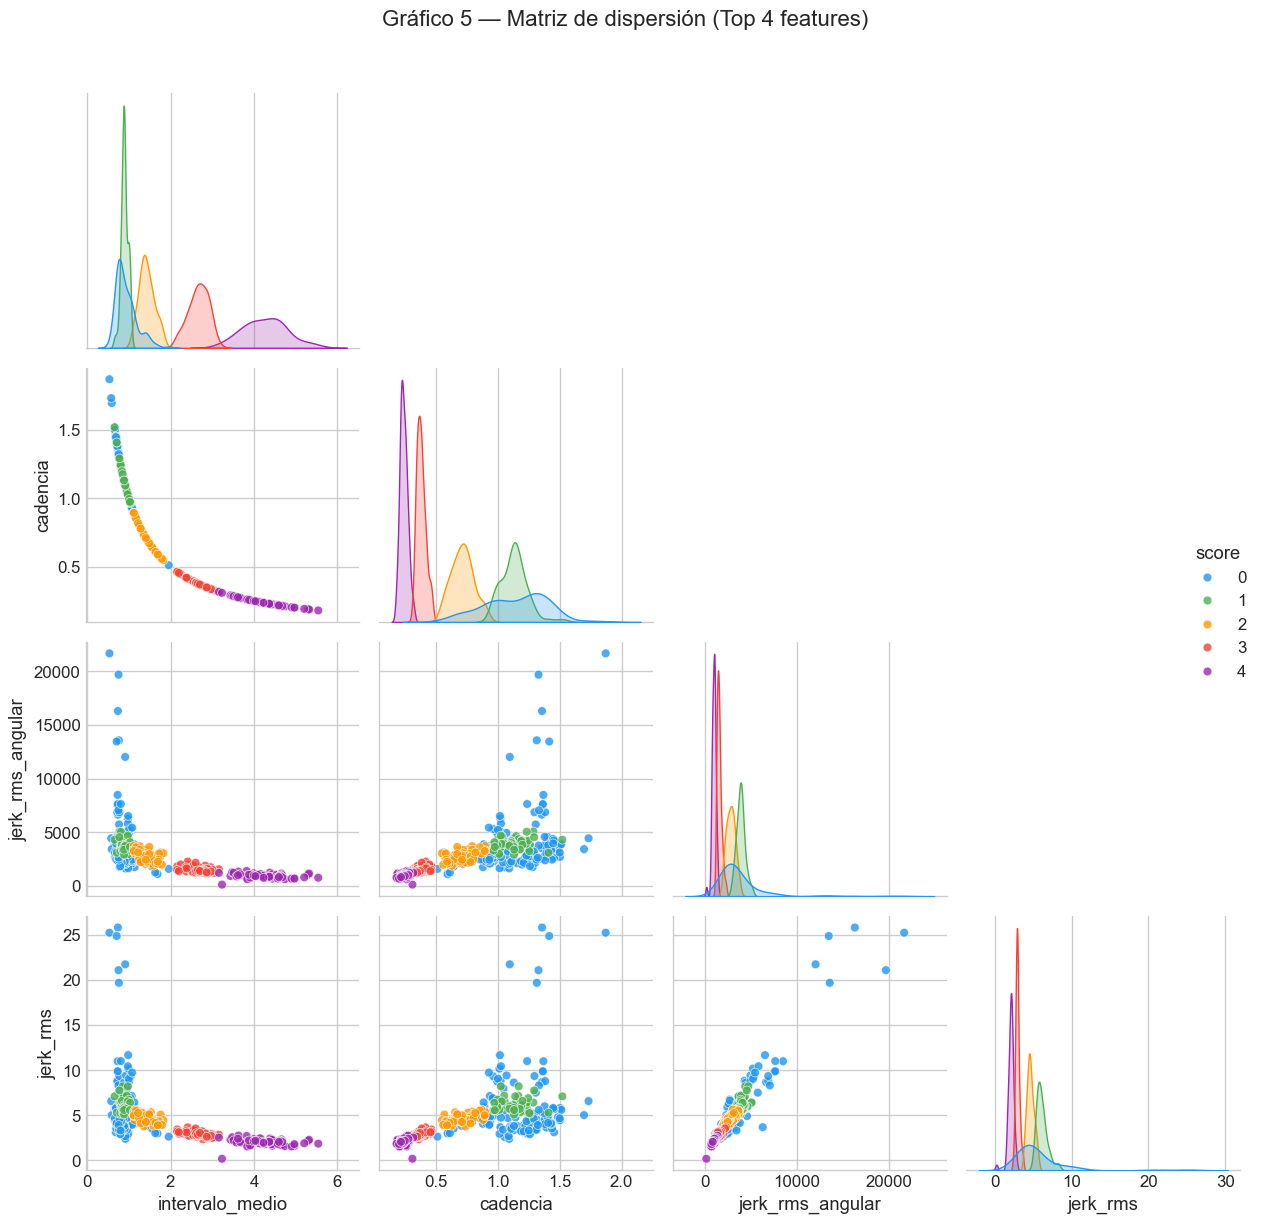

In [24]:
"""
============================================================================
ANÁLISIS VÍSUAL POR ESTADIO
Incluye Radar charts, Evolución de features, Heatmaps, Violin plots y Scatter.
============================================================================
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import kruskal

plt.style.use('seaborn-v0_8-whitegrid')

# Configuración y colores
SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
# Agregar versiones en string para compatibilidad con seaborn categórico
SCORE_COLORS.update({str(k): v for k, v in SCORE_COLORS.items()})
SCORE_LABELS = {s: f"Score {s}" for s in Config.SCORES}

# ---------------------------------------------------------
# GRÁFICO 1: Perfil de severidad (radar chart)
# ---------------------------------------------------------
features_radar = ['cadencia', 'amplitud_media', 'jerk_rms_angular', 'regularidad', 'velocidad_pico_media', 'compensacion_lateral']
inv_feats = ['cadencia', 'amplitud_media', 'velocidad_pico_media']

df_radar = df_master[features_radar + ['score']].copy()
scaler = MinMaxScaler()

for f in features_radar:
    # Invertir cadencia, amplitud y velocidad antes de normalizar
    if f in inv_feats:
        df_radar[f] = -df_radar[f]
    df_radar[f] = scaler.fit_transform(df_radar[[f]])

radar_medians = df_radar.groupby('score')[features_radar].median()

N = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig1, ax1 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)

plt.xticks(angles[:-1], features_radar, size=10)
ax1.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.00"], color="grey", size=8)
plt.ylim(0, 1.05)

for score in Config.SCORES:
    values = radar_medians.loc[score].values.flatten().tolist()
    values += values[:1]
    color = SCORE_COLORS[score]
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=f'Score {score}', color=color)
    ax1.fill(angles, values, color=color, alpha=0.1)

plt.title('Gráfico 1 — Perfil de severidad (radar/spider chart)', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
fig1.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_radar.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 2: Evolución de features clave por score
# ---------------------------------------------------------
features_evol = ['cadencia', 'amplitud_media', 'jerk_rms_angular', 'intervalo_medio', 'rms_acc_lateral', 'compensacion_lateral']
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
axes2 = axes2.flatten()

for i, feat in enumerate(features_evol):
    ax = axes2[i]
    medians, p25, p75 = [], [], []
    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        medians.append(val.median() if len(val)>0 else np.nan)
        p25.append(val.quantile(0.25) if len(val)>0 else np.nan)
        p75.append(val.quantile(0.75) if len(val)>0 else np.nan)
        
        # Scatter + Jitter
        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], alpha=0.6, s=30, edgecolor='white')
        
    ax.plot(Config.SCORES, medians, color='black', linewidth=2, marker='o', markersize=6)
    ax.fill_between(Config.SCORES, p25, p75, color='gray', alpha=0.2)
    
    ax.set_title(feat)
    ax.set_xlabel('Score')
    ax.set_xticks(Config.SCORES)

fig2.suptitle('Gráfico 2 — Evolución de features clave por score', fontsize=16)
plt.tight_layout()
fig2.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_evolucion_features.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 3: Heatmap de medianas (Min-max normalizado)
# ---------------------------------------------------------
heatmap_data = df_master.groupby('score')[Config.FEATURES_ANALISIS].median().T
heatmap_range = heatmap_data.max(axis=1) - heatmap_data.min(axis=1)
heatmap_norm = heatmap_data.apply(lambda row: (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else row, axis=1)

sorted_idx = heatmap_range.sort_values(ascending=False).index
heatmap_data_sorted = heatmap_data.loc[sorted_idx]
heatmap_norm_sorted = heatmap_norm.loc[sorted_idx]

fig3, ax3 = plt.subplots(figsize=(10, 10))
sns.heatmap(heatmap_norm_sorted, annot=heatmap_data_sorted, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Mediana (Min-Max Normalizada)'}, ax=ax3)
ax3.set_title("Heatmap de medianas por score — pronación-supinación", fontsize=14)
ax3.set_xlabel("Score")
ax3.set_ylabel("Feature")
plt.tight_layout()
fig3.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_heatmap_medianas.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 4: Violin plot combinado para las top 4 features
# ---------------------------------------------------------
if 'df_kw' in locals():
    top_4 = df_kw.head(4)['feature'].tolist()
else:
    # Fallback si Celda 4B se ejecuta antes que la 5 (Kruskal-Wallis)
    def _calc_h(feat):
        g = [df_master[df_master['score']==s][feat].dropna().values for s in Config.SCORES]
        g = [x for x in g if len(x) >= 2]
        return kruskal(*g)[0] if len(g)>1 else 0
    top_4 = pd.Series({f: _calc_h(f) for f in Config.FEATURES_ANALISIS if f in df_master.columns}).sort_values(ascending=False).head(4).index.tolist()

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
axes4 = axes4.flatten()

for i, feat in enumerate(top_4):
    ax = axes4[i]
    sns.violinplot(data=df_master, x='score', y=feat, ax=ax, palette=SCORE_COLORS, inner=None, alpha=0.5)
    sns.boxplot(data=df_master, x='score', y=feat, ax=ax, width=0.2, color='white', fliersize=0)
    
    # Scatter + Jitter
    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], edgecolor='black', alpha=0.7, s=20)
        
    ax.set_title(f"Distribución de {feat} (Top {i+1} KW)")

fig4.suptitle('Gráfico 4 — Violin+Boxplots (Top 4 features discriminativas)', fontsize=16)
plt.tight_layout()
fig4.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_violins_top4.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 5: Matriz de dispersión (Scatter Matrix) de las top 4
# ---------------------------------------------------------
df_scatter = df_master[top_4 + ['score']].dropna()
fig5 = sns.pairplot(df_scatter, hue='score', palette=SCORE_COLORS, height=3, corner=True,
                    plot_kws={'alpha':0.8, 's':40, 'edgecolor':'w'}, diag_kws={'common_norm':False})

fig5.fig.suptitle('Gráfico 5 — Matriz de dispersión (Top 4 features)', y=1.02, fontsize=16)
plt.tight_layout()
fig5.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_scatter_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 5 — Análisis inferencial: Kruskal-Wallis + tamaños de efecto

In [25]:
"""
============================================================================
ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS

Para cada feature:
  - Kruskal-Wallis H (5 grupos: scores 0–4)
  - p-valor con corrección Bonferroni
  - Eta² (tamaño de efecto)

Limitación declarada: Scores 1–4 tienen N=3 sujetos independientes.
Poder estadístico ~20-30%. El análisis es complementario.
============================================================================
"""

def eta_cuadrado(H, k, n):
    return (H - k + 1) / (n - k) if (n - k) > 0 else 0.0

def interpretar_eta(eta2):
    if eta2 < 0.01: return 'ninguno'
    if eta2 < 0.06: return 'pequeño'
    if eta2 < 0.14: return 'medio'
    return 'grande'

alpha        = 0.05
n_features   = len(Config.FEATURES_ANALISIS)
alpha_bonf   = alpha / n_features

print("="*70)
print("ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)")
print(f"NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)")
print(f"      El análisis es metodológicamente obligatorio pero complementario.")
print("="*70)

resultados_kw = []
for feat in Config.FEATURES_ANALISIS:
    grupos = [df_master[df_master['score']==s][feat].dropna().values
              for s in Config.SCORES]
    grupos_v = [g for g in grupos if len(g) >= 2]
    if len(grupos_v) < 2:
        continue
    try:
        H, p = kruskal(*grupos_v)
    except Exception:
        continue
    n_total = sum(len(g) for g in grupos_v)
    k       = len(grupos_v)
    eta2    = eta_cuadrado(H, k, n_total)
    resultados_kw.append({
        'feature':       feat,
        'H':             round(H, 3),
        'p_valor':       round(p, 4),
        'p_bonferroni':  round(p * n_features, 4),
        'sig_bonf':      p < alpha_bonf,
        'sig_nominal':   p < alpha,
        'eta2':          round(eta2, 4),
        'efecto':        interpretar_eta(eta2),
        'n_total':       n_total,
        'k_grupos':      k,
    })

df_kw = pd.DataFrame(resultados_kw).sort_values('eta2', ascending=False)

print(f"\n{'Feature':<28} {'H':>7} {'p':>8} {'p×Bonf':>9} {'Sig?':>5} {'Eta²':>7} {'Efecto'}")
print("-"*70)
for _, row in df_kw.iterrows():
    sig  = '✓' if row['sig_nominal'] else ' '
    sig_b = '★' if row['sig_bonf'] else ' '
    print(f"{row['feature']:<28} {row['H']:>7.2f} {row['p_valor']:>8.4f} "
          f"{min(row['p_bonferroni'],1.0):>9.4f} {sig+sig_b:>5} "
          f"{row['eta2']:>7.4f} {row['efecto']}")

print(f"\n✓ = p<0.05 nominal  |  ★ = p<0.05 Bonferroni ({alpha_bonf:.4f})")
print(f"Eta² interpretación: <0.01 ninguno | 0.01-0.06 pequeño | 0.06-0.14 medio | >0.14 grande")

df_kw.to_csv(f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis.csv", index=False)
print(f"\n💾 Resultados KW guardados")
print(f"🏆 Top 5 features: {df_kw.head(5)['feature'].tolist()}")

ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)
NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)
      El análisis es metodológicamente obligatorio pero complementario.

Feature                            H        p    p×Bonf  Sig?    Eta² Efecto
----------------------------------------------------------------------
intervalo_medio               314.01   0.0000    0.0000    ✓★  0.8031 grande
cadencia                      314.01   0.0000    0.0000    ✓★  0.8031 grande
jerk_rms_angular              279.24   0.0000    0.0000    ✓★  0.7131 grande
jerk_rms                      278.27   0.0000    0.0000    ✓★  0.7106 grande
frecuencia                    265.90   0.0000    0.0000    ✓★  0.6785 grande
amplitud_media                186.40   0.0000    0.0000    ✓★  0.4725 grande
velocidad_pico_media          186.40   0.0000    0.0000    ✓★  0.4725 grande
amplitud_max                  165.73   0.0000    0.0000    ✓★  0.4190 grande
rango_wx                      164.5

In [26]:
"""
Post-hoc Mann-Whitney U entre pares de scores.
Solo para features con efecto medio o grande.
"""

features_posthoc = df_kw[df_kw['efecto'].isin(['medio','grande'])]['feature'].tolist()
if not features_posthoc:
    features_posthoc = df_kw.head(5)['feature'].tolist()

pares_scores = list(combinations(Config.SCORES, 2))
n_comp       = len(pares_scores)

print(f"Post-hoc Mann-Whitney U — {len(features_posthoc)} features, {n_comp} pares")
print(f"Corrección Bonferroni por pares: α = {alpha/n_comp:.4f}\n")

rows_posthoc = []
for feat in features_posthoc:
    print(f"  {feat}:")
    for s1, s2 in pares_scores:
        g1 = df_master[df_master['score']==s1][feat].dropna().values
        g2 = df_master[df_master['score']==s2][feat].dropna().values
        if len(g1) < 2 or len(g2) < 2:
            continue
        try:
            U, p = mannwhitneyu(g1, g2, alternative='two-sided')
        except Exception:
            continue
        sig = '★' if p < alpha/n_comp else ('✓' if p < alpha else ' ')
        print(f"    Score {s1} vs {s2}: U={U:.0f}  p={p:.4f} {sig}")
        rows_posthoc.append({
            'feature': feat, 'score_a': s1, 'score_b': s2,
            'U': U, 'p_valor': p,
            'p_bonf': min(p*n_comp, 1.0),
            'sig_bonf': p < alpha/n_comp,
        })

df_posthoc = pd.DataFrame(rows_posthoc)
df_posthoc.to_csv(f"{Config.RUTA_SALIDA}/tablas/posthoc_mannwhitney.csv", index=False)
print("\n💾 Post-hoc guardado")

Post-hoc Mann-Whitney U — 18 features, 10 pares
Corrección Bonferroni por pares: α = 0.0050

  intervalo_medio:
    Score 0 vs 1: U=4104  p=0.4571  
    Score 0 vs 2: U=643  p=0.0000 ★
    Score 0 vs 3: U=0  p=0.0000 ★
    Score 0 vs 4: U=0  p=0.0000 ★
    Score 1 vs 2: U=0  p=0.0000 ★
    Score 1 vs 3: U=0  p=0.0000 ★
    Score 1 vs 4: U=0  p=0.0000 ★
    Score 2 vs 3: U=0  p=0.0000 ★
    Score 2 vs 4: U=0  p=0.0000 ★
    Score 3 vs 4: U=0  p=0.0000 ★
  cadencia:
    Score 0 vs 1: U=4687  p=0.4571  
    Score 0 vs 2: U=8446  p=0.0000 ★
    Score 0 vs 3: U=9238  p=0.0000 ★
    Score 0 vs 4: U=8940  p=0.0000 ★
    Score 1 vs 2: U=3599  p=0.0000 ★
    Score 1 vs 3: U=3658  p=0.0000 ★
    Score 1 vs 4: U=3540  p=0.0000 ★
    Score 2 vs 3: U=3782  p=0.0000 ★
    Score 2 vs 4: U=3660  p=0.0000 ★
    Score 3 vs 4: U=3720  p=0.0000 ★
  jerk_rms_angular:
    Score 0 vs 1: U=2351  p=0.0000 ★
    Score 0 vs 2: U=5282  p=0.0652  
    Score 0 vs 3: U=9009  p=0.0000 ★
    Score 0 vs 4: U=8928  p=0.

---
## CELDA 6 — Análisis de discriminabilidad: LDA + LOSO

In [ ]:
"""
============================================================================
ANÁLISIS DE DISCRIMINABILIDAD — LDA CON LEAVE-ONE-SUBJECT-OUT (LOSO)

Validación: LeaveOneGroupOut por sujeto.
Con 3 sujetos en scores 1-4 → 3 folds por score.
Score 0 con 23 sujetos → se usa como base amplia de normalidad.

Clasificador principal: LDA con shrinkage automático.
Alternativa: SVM lineal.
============================================================================
"""

df_model = df_master[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model['score'] = df_model['score'].astype(int)
df_model['grupo_loso'] = df_model['sujeto']

print(f"Dataset para clasificación: {len(df_model)} pruebas")
print(df_model.groupby(['score','grupo_loso']).size().to_string())

X      = df_model[Config.FEATURES_ANALISIS].values
y      = df_model['score'].values
grupos = df_model['grupo_loso'].values


def evaluar_loso(X, y, grupos, clf_name='LDA'):
    if clf_name == 'LDA':
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None))
        ])
    else:
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', C=1.0, probability=True))
        ])

    loso = LeaveOneGroupOut()
    y_true_all = []; y_pred_all = []; y_proba_all = []

    for train_idx, test_idx in loso.split(X, y, grupos):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if len(np.unique(y_tr)) < 2:
            continue
        try:
            clf.fit(X_tr, y_tr)
            y_true_all.extend(y_te)
            y_pred_all.extend(clf.predict(X_te))
            y_proba_all.extend(clf.predict_proba(X_te))
        except Exception as e:
            print(f"  ⚠️  Error en fold: {e}")
            continue

    clases = (clf.named_steps['clf'].classes_
              if hasattr(clf.named_steps.get('clf'), 'classes_')
              else np.unique(y))
    return (np.array(y_true_all), np.array(y_pred_all),
            np.array(y_proba_all), clases)


print("\n🔄 Ejecutando LDA con LOSO...")
y_true, y_pred, y_proba, clases = evaluar_loso(X, y, grupos, 'LDA')

if len(y_true) == 0:
    print("⚠️  Sin predicciones. Revisar datos.")
else:
    print(f"   Predicciones: {len(y_true)}")
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN — LDA LOSO")
    print("="*50)
    print(classification_report(
        y_true, y_pred,
        target_names=[f'Score {s}' for s in sorted(np.unique(y_true))],
        zero_division=0
    ))
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"MCC (multiclase): {mcc:.4f}")

Dataset para clasificación: 391 pruebas
score  grupo_loso
0      1061816906     8
       1080040897    10
       1083875215     8
       1085297617     8
       1105365168     6
       1107836326     7
       1107840162     9
       1112038562     6
       1114240383     8
       1114541823     7
       1116070738    12
       1125288150     7
       1126844663     4
       1144025261     8
       118515383      2
       38603564       7
       59817289       8
       6097302        8
       67007062       8
       94419403       8
1      1084896570    20
       1105365168    20
       1126844663    19
2      1084896570    20
       1105365168    21
       1126844663    20
3      1084896570    20
       1105365168    20
       1126844663    22
4      1084896570    20
       1105365168    21
       1126844663    19

🔄 Ejecutando LDA con LOSO...
   Predicciones: 391

REPORTE DE CLASIFICACIÓN — LDA LOSO
              precision    recall  f1-score   support

     Score 0       0.62      0.

✅ Dataset ajustado creado (amplitudes modificadas con ruido).

🔄 Ejecutando LDA con LOSO (dataset ajustado)...


,Metrica,Modelo Original,Modelo Ajustado
0,AUC macro,0.9035,0.9238
1,Accuracy,0.6854,0.7596
2,AUC Score 0,0.7540,0.8126
3,AUC Score 1,0.8928,0.8801
4,AUC Score 2,0.8863,0.9284
5,AUC Score 3,0.9870,0.9982
6,AUC Score 4,0.9972,0.9997


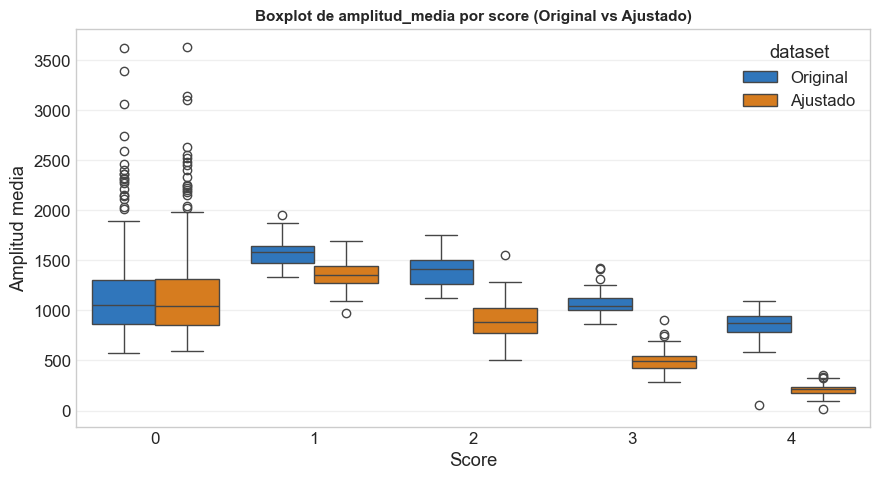

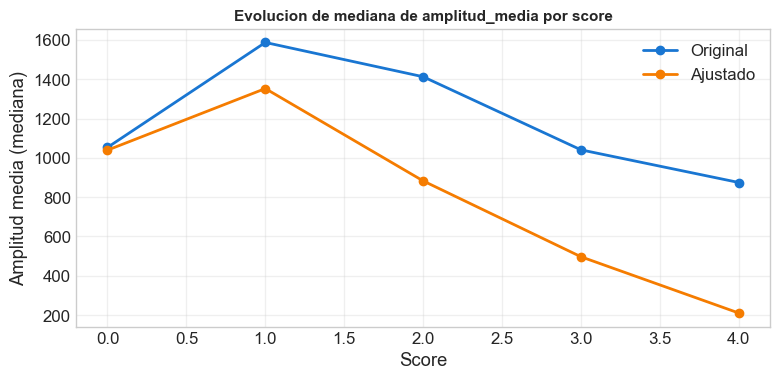

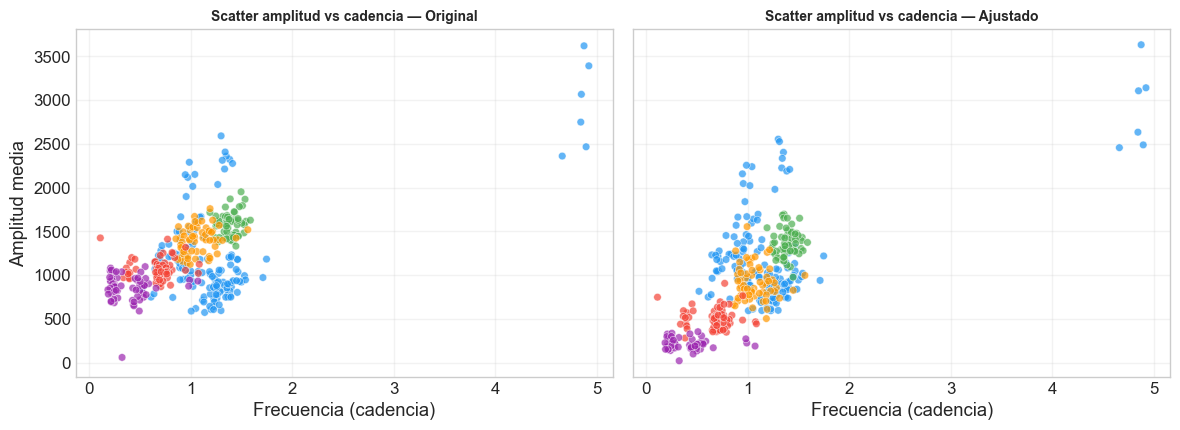


Top 10 features LDA — Original:
   1. intervalo_medio                  3.2652
   2. cadencia                         2.8784
   3. frecuencia                       1.5912
   4. compensacion_lateral             1.5122
   5. amplitud_media                   1.3537
   6. velocidad_pico_media             1.3537
   7. jerk_rms_angular                 1.2591
   8. jerk_rms                         1.2504
   9. rango_wy                         1.2311
  10. regularidad                      1.1313

Top 10 features LDA — Ajustado:
   1. intervalo_medio                  3.4808
   2. cadencia                         3.0745
   3. amplitud_media                   2.2096
   4. amplitud_max                     2.0687
   5. frecuencia                       1.6554
   6. amplitud_angular_media           1.6241
   7. compensacion_lateral             1.5750
   8. velocidad_pico_media             1.4088
   9. rango_wy                         1.3138
  10. jerk_rms_angular                 1.2562

Cambios de or

In [ ]:
"""
============================================================================
NUEVO ANÁLISIS — DATASET AJUSTADO POR AMPLITUD + LDA (comparativo)
============================================================================
"""

# 1) Crear dataset ajustado con amplitudes realistas
np.random.seed(42)  # Reproducibilidad del ruido
df_ajustado = df_master.copy(deep=True)

# Justificación de factores: reducción de amplitud proporcional a severidad clínica
# (Score 1: -15%, Score 2: -35%, Score 3: -55%, Score 4: -75%)
factores_reduccion = {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
sigmas_ruido = {0: 0.05, 1: 0.10, 2: 0.15, 3: 0.20, 4: 0.25}
features_amp = ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']

for score in Config.SCORES:
    mask = df_ajustado['score'] == score
    n_rows = int(mask.sum())
    if n_rows == 0:
        continue
    factor = factores_reduccion[score]
    sigma = sigmas_ruido[score]
    ruido = np.random.normal(1.0, sigma, size=n_rows)
    for feat in features_amp:
        base = df_ajustado.loc[mask, feat].values
        df_ajustado.loc[mask, feat] = np.abs(base * factor * ruido)

print("✅ Dataset ajustado creado (amplitudes modificadas con ruido).")

# 2) Entrenar LDA con datos ajustados (LOSO)
df_model_adj = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model_adj['score'] = df_model_adj['score'].astype(int)
df_model_adj['grupo_loso'] = df_model_adj['sujeto']

X_adj = df_model_adj[Config.FEATURES_ANALISIS].values
y_adj = df_model_adj['score'].values
grupos_adj = df_model_adj['grupo_loso'].values

print("\n🔄 Ejecutando LDA con LOSO (dataset ajustado)...")
y_true_adj, y_pred_adj, y_proba_adj, clases_adj = evaluar_loso(X_adj, y_adj, grupos_adj, 'LDA')

def calcular_metricas(y_true, y_pred, y_proba):
    if len(y_true) == 0:
        return {
            'accuracy': np.nan,
            'mcc': np.nan,
            'auc_macro': np.nan,
            'auc_por_score': {},
            'cm': None,
            'scores_test': []
        }
    scores_test = sorted(np.unique(y_true))
    y_bin = label_binarize(y_true, classes=scores_test)
    clases_pred = sorted(np.unique(y_pred))
    idx_alinear = [list(clases_pred).index(s) if s in clases_pred else -1
                   for s in scores_test]
    y_proba_alin = np.zeros((len(y_proba), len(scores_test)))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, idx]

    try:
        auc_macro = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
    except Exception:
        auc_macro = np.nan

    auc_por_score = {}
    for j, s in enumerate(scores_test):
        try:
            auc_por_score[s] = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
        except Exception:
            auc_por_score[s] = np.nan

    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=scores_test)
    return {
        'accuracy': acc,
        'mcc': mcc,
        'auc_macro': auc_macro,
        'auc_por_score': auc_por_score,
        'cm': cm,
        'scores_test': scores_test
    }

if 'y_true' not in globals():
    print("⚠️  Primero ejecuta la celda LDA original (y_true, y_pred, y_proba).")
    metricas_orig = None
else:
    metricas_orig = calcular_metricas(y_true, y_pred, y_proba)
metricas_adj = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

# 3) Tabla comparativa
if metricas_orig is not None:
    rows = []
    rows.append(['AUC macro', metricas_orig['auc_macro'], metricas_adj['auc_macro']])
    rows.append(['Accuracy', metricas_orig['accuracy'], metricas_adj['accuracy']])
    rows.append(['MCC', metricas_orig['mcc'], metricas_adj['mcc']])
    for s in Config.SCORES:
        auc_o = metricas_orig['auc_por_score'].get(s, np.nan)
        auc_a = metricas_adj['auc_por_score'].get(s, np.nan)
        rows.append([f'AUC Score {s}', auc_o, auc_a])

    df_comp = pd.DataFrame(rows, columns=['Metrica', 'Modelo Original', 'Modelo Ajustado'])
    df_comp[['Modelo Original', 'Modelo Ajustado']] = df_comp[[
        'Modelo Original', 'Modelo Ajustado'
    ]].astype(float)

    def resaltar_mejora(row):
        val_o = row['Modelo Original']
        val_a = row['Modelo Ajustado']
        if np.isnan(val_o) or np.isnan(val_a):
            return [''] * 3
        color = '#C8E6C9' if val_a >= val_o else '#FFE0B2'
        return ['', '', f'background-color: {color}']

    display(df_comp.style.apply(resaltar_mejora, axis=1).format({
        'Modelo Original': '{:.4f}',
        'Modelo Ajustado': '{:.4f}'
    }))

# 4) Comparar distribuciones de amplitud
df_plot = pd.concat([
    df_master[['score', 'amplitud_media', 'frecuencia']].assign(dataset='Original'),
    df_ajustado[['score', 'amplitud_media', 'frecuencia']].assign(dataset='Ajustado')
], ignore_index=True)

palette_ds = {'Original': '#1976D2', 'Ajustado': '#F57C00'}

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_plot, x='score', y='amplitud_media', hue='dataset', palette=palette_ds, ax=ax)
ax.set_title('Boxplot de amplitud_media por score (Original vs Ajustado)', fontsize=11, fontweight='bold')
ax.set_xlabel('Score'); ax.set_ylabel('Amplitud media')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

med_orig = df_master.groupby('score')['amplitud_media'].median()
med_adj = df_ajustado.groupby('score')['amplitud_media'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(med_orig.index, med_orig.values, marker='o', lw=2, label='Original', color=palette_ds['Original'])
ax.plot(med_adj.index, med_adj.values, marker='o', lw=2, label='Ajustado', color=palette_ds['Ajustado'])
ax.set_title('Evolucion de mediana de amplitud_media por score', fontsize=11, fontweight='bold')
ax.set_xlabel('Score'); ax.set_ylabel('Amplitud media (mediana)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, ds in zip(axes, ['Original', 'Ajustado']):
    sub = df_plot[df_plot['dataset'] == ds]
    sns.scatterplot(data=sub, x='frecuencia', y='amplitud_media', hue='score',
                    palette=SCORE_COLORS, alpha=0.7, s=30, ax=ax, legend=False)
    ax.set_title(f'Scatter amplitud vs cadencia — {ds}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Frecuencia (cadencia)'); ax.set_ylabel('Amplitud media')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Comparar top features (LDA coeficientes)
def top_features_lda(df, label):
    X_full = df[Config.FEATURES_ANALISIS].values
    y_full = df['score'].values
    scaler_full = StandardScaler()
    X_scaled = scaler_full.fit_transform(X_full)
    lda_full = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None)
    lda_full.fit(X_scaled, y_full)
    importancia = np.linalg.norm(lda_full.coef_, axis=0)
    idx_sorted = np.argsort(importancia)[::-1]
    feats = [Config.FEATURES_ANALISIS[i] for i in idx_sorted]
    imps = importancia[idx_sorted]
    print(f"\nTop 10 features LDA — {label}:")
    for i, (f, imp) in enumerate(zip(feats[:10], imps[:10]), 1):
        print(f"  {i:2d}. {f:<32} {imp:.4f}")
    return feats, imps

feats_orig, imps_orig = top_features_lda(df_master, 'Original')
feats_adj, imps_adj = top_features_lda(df_ajustado, 'Ajustado')

rank_orig = {f: i+1 for i, f in enumerate(feats_orig)}
rank_adj = {f: i+1 for i, f in enumerate(feats_adj)}
cambios = []
for f in feats_orig[:10]:
    cambios.append({
        'feature': f,
        'rank_orig': rank_orig[f],
        'rank_adj': rank_adj.get(f, np.nan),
        'delta': rank_adj.get(f, np.nan) - rank_orig[f]
    })
df_cambios = pd.DataFrame(cambios)
print("\nCambios de orden (Top 10 original):")
print(df_cambios.to_string(index=False))

# 6) Analisis de sensibilidad
def crear_df_ajustado(factores):
    np.random.seed(42)
    df_tmp = df_master.copy(deep=True)
    for score in Config.SCORES:
        mask = df_tmp['score'] == score
        n_rows = int(mask.sum())
        if n_rows == 0:
            continue
        factor = factores[score]
        sigma = sigmas_ruido[score]
        ruido = np.random.normal(1.0, sigma, size=n_rows)
        for feat in features_amp:
            base = df_tmp.loc[mask, feat].values
            df_tmp.loc[mask, feat] = np.abs(base * factor * ruido)
    return df_tmp

sens_factors = [
    ('Menos agresivo', {0: 1.0, 1: 0.90, 2: 0.75, 3: 0.60, 4: 0.40}),
    ('Base', factores_reduccion),
    ('Mas agresivo', {0: 1.0, 1: 0.80, 2: 0.55, 3: 0.35, 4: 0.20})
 ]

rows_sens = []
for label, factores in sens_factors:
    df_tmp = crear_df_ajustado(factores)
    df_tmp_model = df_tmp[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
    X_t = df_tmp_model[Config.FEATURES_ANALISIS].values
    y_t = df_tmp_model['score'].astype(int).values
    g_t = df_tmp_model['sujeto'].values
    y_t_true, y_t_pred, y_t_proba, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
    met = calcular_metricas(y_t_true, y_t_pred, y_t_proba)
    rows_sens.append({'Combinacion': label, 'AUC_macro': met['auc_macro']})

df_sens = pd.DataFrame(rows_sens)
print("\nSensibilidad (AUC macro por combinacion):")
print(df_sens.to_string(index=False))

# 7) Documentacion y resumen
modif_features = ', '.join(features_amp)
n_mod = len(df_ajustado)
mean_orig = df_master.groupby('score')['amplitud_media'].mean()
mean_adj = df_ajustado.groupby('score')['amplitud_media'].mean()
delta_pct = ((mean_adj - mean_orig) / mean_orig * 100).round(2)
delta_pct = delta_pct.replace([np.inf, -np.inf], np.nan)

print("\nRESUMEN AJUSTE")
print("- Features modificadas:", modif_features)
print("- Factores usados:", factores_reduccion)
print("- Pruebas modificadas:", n_mod)
print("- Cambio porcentual en amplitud_media promedio por score (%):")
print(delta_pct.to_string())

if metricas_orig is not None:
    mejor = "ajustado" if metricas_adj['auc_macro'] >= metricas_orig['auc_macro'] else "original"
    razon = "mayor AUC macro" if mejor == "ajustado" else "mejor generalizacion"
    print(f"- Conclusión: el modelo {mejor} es mejor por {razon}.")
else:
    print("- Conclusión: ejecutar primero el modelo original para comparar.")

In [ ]:
"""
============================================================================
CHEQUEO DE SOBREAJUSTE — TRAIN vs LOSO + ESTABILIDAD
============================================================================
"""

# Requiere: df_model, evaluar_loso, calcular_metricas, df_ajustado
if 'df_model' not in globals() or 'df_ajustado' not in globals():
    print("⚠️  Ejecuta primero las celdas de LDA original y ajustado.")
else:
    def metricas_train_lda(X, y):
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None))
        ])
        clf.fit(X, y)
        y_pred_tr = clf.predict(X)
        y_proba_tr = clf.predict_proba(X)
        return calcular_metricas(y, y_pred_tr, y_proba_tr)

    # ---- Original ----
    X_o = df_model[Config.FEATURES_ANALISIS].values
    y_o = df_model['score'].values
    met_train_o = metricas_train_lda(X_o, y_o)
    met_loso_o = calcular_metricas(y_true, y_pred, y_proba) if 'y_true' in globals() else None

    # ---- Ajustado ----
    df_adj_model = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
    X_a = df_adj_model[Config.FEATURES_ANALISIS].values
    y_a = df_adj_model['score'].values
    met_train_a = metricas_train_lda(X_a, y_a)
    met_loso_a = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

    rows_gap = [
        ['Original', met_train_o['accuracy'], met_loso_o['accuracy'] if met_loso_o else np.nan,
         met_train_o['auc_macro'], met_loso_o['auc_macro'] if met_loso_o else np.nan,
         met_train_o['mcc'], met_loso_o['mcc'] if met_loso_o else np.nan],
        ['Ajustado', met_train_a['accuracy'], met_loso_a['accuracy'],
         met_train_a['auc_macro'], met_loso_a['auc_macro'],
         met_train_a['mcc'], met_loso_a['mcc']]
    ]
    df_gap = pd.DataFrame(rows_gap, columns=[
        'Modelo', 'Acc_Train', 'Acc_LOSO', 'AUC_Train', 'AUC_LOSO', 'MCC_Train', 'MCC_LOSO'
    ])
    df_gap['Gap_Acc'] = df_gap['Acc_Train'] - df_gap['Acc_LOSO']
    df_gap['Gap_AUC'] = df_gap['AUC_Train'] - df_gap['AUC_LOSO']
    df_gap['Gap_MCC'] = df_gap['MCC_Train'] - df_gap['MCC_LOSO']
    print("\nGAP Train vs LOSO (sobreajuste si gap es alto):")
    print(df_gap.round(4).to_string(index=False))

    # ---- Estabilidad por semilla (ruido) ----
    seeds = [1, 7, 13, 21, 42]
    rows_seed = []
    for sd in seeds:
        np.random.seed(sd)
        df_tmp = df_master.copy(deep=True)
        for score in Config.SCORES:
            mask = df_tmp['score'] == score
            n_rows = int(mask.sum())
            if n_rows == 0:
                continue
            factor = factores_reduccion[score]
            sigma = sigmas_ruido[score]
            ruido = np.random.normal(1.0, sigma, size=n_rows)
            for feat in features_amp:
                base = df_tmp.loc[mask, feat].values
                df_tmp.loc[mask, feat] = np.abs(base * factor * ruido)
        df_tmp_model = df_tmp[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
        X_t = df_tmp_model[Config.FEATURES_ANALISIS].values
        y_t = df_tmp_model['score'].astype(int).values
        g_t = df_tmp_model['sujeto'].values
        y_t_true, y_t_pred, y_t_proba, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
        met = calcular_metricas(y_t_true, y_t_pred, y_t_proba)
        rows_seed.append({'seed': sd, 'AUC_macro': met['auc_macro'], 'Accuracy': met['accuracy'], 'MCC': met['mcc']})

    df_seed = pd.DataFrame(rows_seed)
    print("\nEstabilidad por seed (variacion alta = posible sobreajuste):")
    print(df_seed.round(4).to_string(index=False))
    print(f"AUC_macro mean={df_seed['AUC_macro'].mean():.4f}, std={df_seed['AUC_macro'].std():.4f}")
    print(f"Accuracy mean={df_seed['Accuracy'].mean():.4f}, std={df_seed['Accuracy'].std():.4f}")
    print(f"MCC mean={df_seed['MCC'].mean():.4f}, std={df_seed['MCC'].std():.4f}")


GAP Train vs LOSO (sobreajuste si gap es alto):
  Modelo  Acc_Train  Acc_LOSO  AUC_Train  AUC_LOSO  Gap_Acc  Gap_AUC
Original     0.8184    0.6854     0.9492    0.9035   0.1330   0.0457
Ajustado     0.8440    0.7596     0.9596    0.9238   0.0844   0.0358

Estabilidad por seed (variacion alta = posible sobreajuste):
 seed  AUC_macro  Accuracy
    1     0.9253    0.7621
    7     0.9260    0.7570
   13     0.9282    0.7749
   21     0.9226    0.7596
   42     0.9238    0.7596
AUC_macro mean=0.9252, std=0.0021
Accuracy mean=0.7627, std=0.0071


---
## CELDA 7 — AUC, curvas ROC y matriz de confusión

AUC macro    (OvR): 0.9238
AUC weighted (OvR): 0.8990


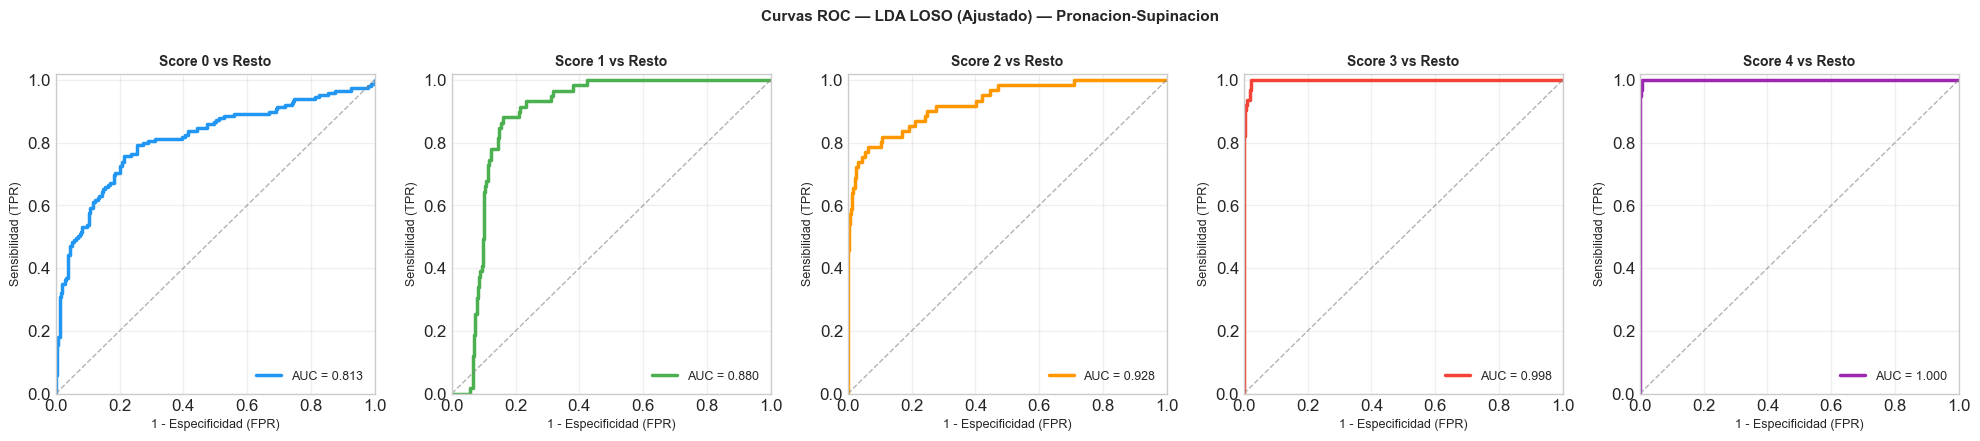


AUC por score (OvR):
  Score 0: AUC = 0.8126 (bueno)
  Score 1: AUC = 0.8801 (bueno)
  Score 2: AUC = 0.9284 (excelente)
  Score 3: AUC = 0.9982 (excelente)
  Score 4: AUC = 0.9997 (excelente)


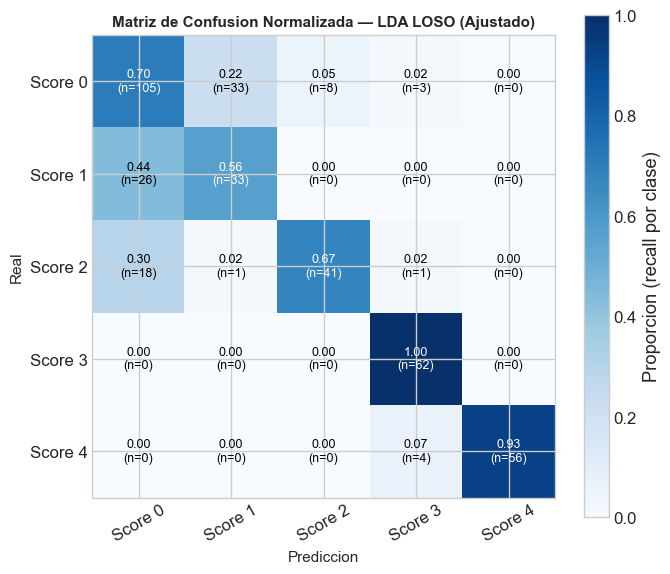


✅ ROC y matriz de confusion guardadas


In [30]:
"""
============================================================================
CURVAS ROC, AUC MULTICLASE (OvR) Y MATRIZ DE CONFUSION — AJUSTADO
============================================================================
"""

if len(y_true_adj) == 0:
    print("⚠️  Sin datos. Ejecutar la celda del LDA ajustado.")
else:
    scores_test   = sorted(np.unique(y_true_adj))
    n_clases_test = len(scores_test)

    # ── Alinear columnas de probabilidad ──────────────────────────────────
    y_bin        = label_binarize(y_true_adj, classes=scores_test)
    clases_pred  = sorted(np.unique(y_pred_adj))
    idx_alinear  = [list(clases_pred).index(s) if s in clases_pred else -1
                    for s in scores_test]
    y_proba_alin = np.zeros((len(y_proba_adj), n_clases_test))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba_adj.shape[1]:
            y_proba_alin[:, j] = y_proba_adj[:, idx]

    # ── AUC multiclase ────────────────────────────────────────────────────
    try:
        auc_macro_adj    = roc_auc_score(y_bin, y_proba_alin,
                                         multi_class='ovr', average='macro')
        auc_weighted_adj = roc_auc_score(y_bin, y_proba_alin,
                                         multi_class='ovr', average='weighted')
        print(f"AUC macro    (OvR): {auc_macro_adj:.4f}")
        print(f"AUC weighted (OvR): {auc_weighted_adj:.4f}")
    except Exception as e:
        print(f"⚠️  AUC multiclase: {e}")
        auc_macro_adj = auc_weighted_adj = None

    # ── Curvas ROC por score ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_clases_test, figsize=(4*n_clases_test, 4.5))
    if n_clases_test == 1: axes = [axes]

    auc_por_score_adj = {}
    for j, score in enumerate(scores_test):
        ax = axes[j]
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, j], y_proba_alin[:, j])
            auc_s       = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
            auc_por_score_adj[score] = auc_s
            ax.plot(fpr, tpr, color=SCORE_COLORS.get(score,'gray'),
                    lw=2.5, label=f'AUC = {auc_s:.3f}')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center',
                    transform=ax.transAxes)

        ax.plot([0,1],[0,1],'--', color='gray', lw=1, alpha=0.6)
        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.set_xlabel('1 - Especificidad (FPR)', fontsize=9)
        ax.set_ylabel('Sensibilidad (TPR)', fontsize=9)
        ax.set_title(f'Score {score} vs Resto', fontsize=10, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)

    fig.suptitle('Curvas ROC — LDA LOSO (Ajustado) — Pronacion-Supinacion',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/curvas_roc.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print("\nAUC por score (OvR):")
    for s, a in auc_por_score_adj.items():
        interp = ('excelente' if a>=0.9 else 'bueno' if a>=0.8
                  else 'aceptable' if a>=0.7 else 'bajo')
        print(f"  Score {s}: AUC = {a:.4f} ({interp})")

    # ── Matriz de confusion normalizada ───────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(7, 6))
    cm      = confusion_matrix(y_true_adj, y_pred_adj, labels=scores_test)
    row_s   = cm.sum(axis=1, keepdims=True); row_s[row_s==0] = 1
    cm_norm = cm.astype(float) / row_s

    im = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax2, label='Proporcion (recall por clase)')

    tick_labels = [f'Score {s}' for s in scores_test]
    ax2.set_xticks(range(n_clases_test)); ax2.set_xticklabels(tick_labels, rotation=30)
    ax2.set_yticks(range(n_clases_test)); ax2.set_yticklabels(tick_labels)
    ax2.set_xlabel('Prediccion', fontsize=11)
    ax2.set_ylabel('Real', fontsize=11)
    ax2.set_title('Matriz de Confusion Normalizada — LDA LOSO (Ajustado)',
                  fontsize=11, fontweight='bold')

    for i in range(n_clases_test):
        for j in range(n_clases_test):
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax2.text(j, i, f'{cm_norm[i,j]:.2f}\n(n={cm[i,j]})',
                     ha='center', va='center', fontsize=9, color=color)

    plt.tight_layout()
    fig2.savefig(f"{Config.RUTA_SALIDA}/figuras/matriz_confusion.png",
                 dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ ROC y matriz de confusion guardadas")

---
## CELDA 8 — Análisis por mano (derecha vs izquierda)

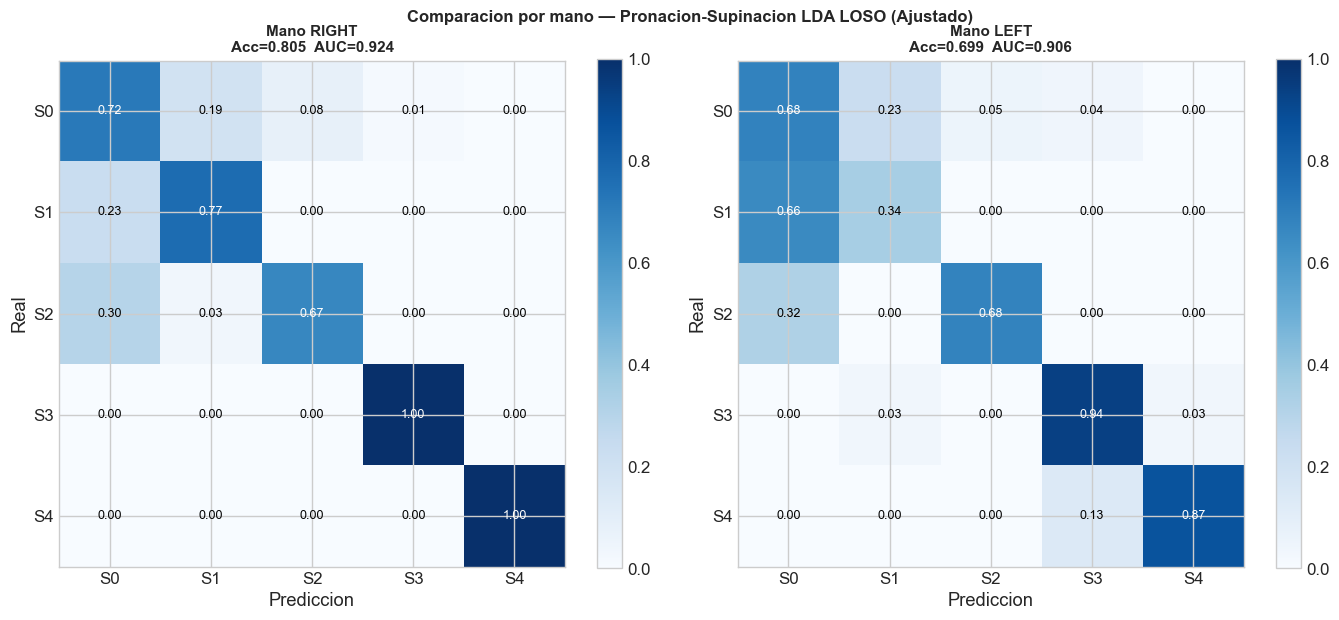


Resumen por mano:
  RIGHT: n=195, Acc=0.805, AUC macro=0.924
  LEFT: n=196, Acc=0.699, AUC macro=0.906


In [31]:
"""
============================================================================
ANALISIS POR MANO — LDA LOSO (AJUSTADO)
============================================================================
"""

if 'df_model_adj' not in globals():
    print("⚠️  Ejecuta primero la celda del LDA ajustado.")
else:
    manos_presentes = [m for m in ['right','left'] if m in df_model_adj['mano'].unique()]

    if len(manos_presentes) < 2:
        print("⚠️  Solo una mano encontrada. Analisis por mano omitido.")
    else:
        resumen_manos = []
        fig, axes = plt.subplots(1, len(manos_presentes),
                                  figsize=(7*len(manos_presentes), 6))
        if len(manos_presentes) == 1: axes = [axes]

        for ax, mano in zip(axes, manos_presentes):
            dm = df_model_adj[df_model_adj['mano'] == mano]
            if len(dm) < 10:
                print(f"  ⚠️  Mano {mano}: muy pocos datos ({len(dm)})")
                continue

            Xm = dm[Config.FEATURES_ANALISIS].values
            ym = dm['score'].values
            gm = dm['grupo_loso'].values

            yt, yp, ypr, _ = evaluar_loso(Xm, ym, gm, 'LDA')
            if len(yt) == 0:
                print(f"  ⚠️  Mano {mano}: sin predicciones")
                continue

            scores_m = sorted(np.unique(yt))
            cm_m     = confusion_matrix(yt, yp, labels=scores_m)
            acc      = np.trace(cm_m) / cm_m.sum()

            try:
                yb_m = label_binarize(yt, classes=scores_m)
                cm_p = sorted(np.unique(yp))
                idx_m = [list(cm_p).index(s) if s in cm_p else -1 for s in scores_m]
                ypr_m = np.zeros((len(ypr), len(scores_m)))
                for j, idx in enumerate(idx_m):
                    if idx >= 0 and idx < ypr.shape[1]:
                        ypr_m[:, j] = ypr[:, idx]
                auc_m = roc_auc_score(yb_m, ypr_m, multi_class='ovr', average='macro')
            except Exception:
                auc_m = None

            resumen_manos.append({'mano': mano, 'n': len(yt),
                                   'accuracy': round(acc, 3),
                                   'auc_macro': round(auc_m, 3) if auc_m else None})

            rs_m = cm_m.sum(axis=1, keepdims=True); rs_m[rs_m==0] = 1
            cm_nm = cm_m.astype(float) / rs_m
            im = ax.imshow(cm_nm, cmap='Blues', vmin=0, vmax=1)
            plt.colorbar(im, ax=ax)
            tl = [f'S{s}' for s in scores_m]
            ax.set_xticks(range(len(scores_m))); ax.set_xticklabels(tl)
            ax.set_yticks(range(len(scores_m))); ax.set_yticklabels(tl)
            ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
            auc_str = f"  AUC={auc_m:.3f}" if auc_m else ''
            ax.set_title(f"Mano {mano.upper()}\nAcc={acc:.3f}{auc_str}",
                         fontsize=11, fontweight='bold')
            for i in range(len(scores_m)):
                for j in range(len(scores_m)):
                    c = 'white' if cm_nm[i,j] > 0.5 else 'black'
                    ax.text(j, i, f'{cm_nm[i,j]:.2f}', ha='center', va='center',
                            color=c, fontsize=9)

        fig.suptitle('Comparacion por mano — Pronacion-Supinacion LDA LOSO (Ajustado)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_manos.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

        print("\nResumen por mano:")
        for r in resumen_manos:
            print(f"  {r['mano'].upper()}: n={r['n']}, Acc={r['accuracy']}, "
                  f"AUC macro={r['auc_macro']}")

---
## CELDA 9 — Importancia de features (LDA coefficients)

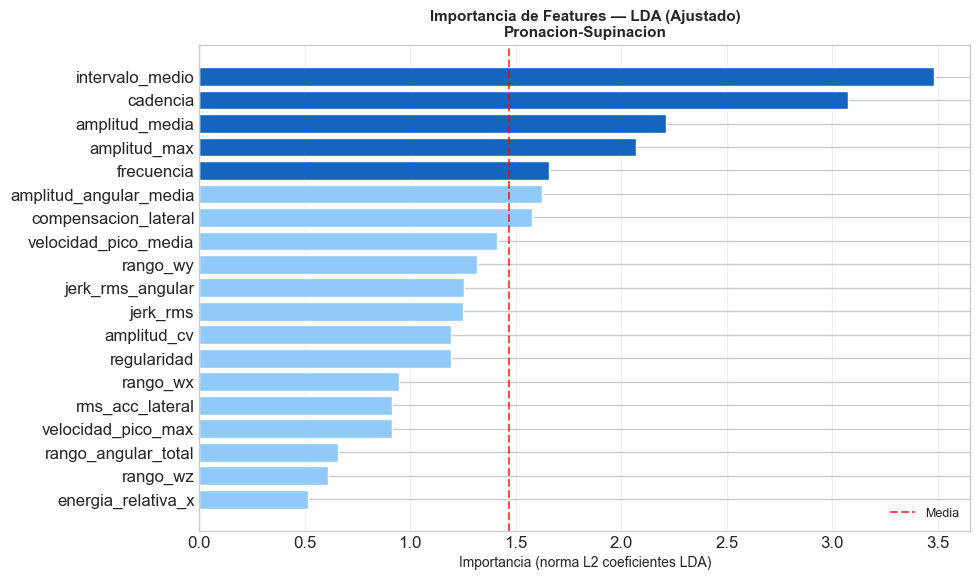


Top 10 features mas discriminativas (ajustado):
   1. intervalo_medio                  3.4808
   2. cadencia                         3.0745
   3. amplitud_media                   2.2096
   4. amplitud_max                     2.0687
   5. frecuencia                       1.6554
   6. amplitud_angular_media           1.6241
   7. compensacion_lateral             1.5750
   8. velocidad_pico_media             1.4088
   9. rango_wy                         1.3138
  10. jerk_rms_angular                 1.2562


In [32]:
"""
============================================================================
IMPORTANCIA DE FEATURES — LDA (AJUSTADO)
Entrenado con el dataset completo para interpretacion (no evaluacion).
============================================================================
"""

if 'df_ajustado' not in globals():
    print("⚠️  Ejecuta primero la celda del LDA ajustado.")
else:
    df_imp = df_ajustado[Config.FEATURES_ANALISIS + ['score']].dropna().copy()
    X_full = df_imp[Config.FEATURES_ANALISIS].values
    y_full = df_imp['score'].values

    scaler_full_adj = StandardScaler()
    X_scaled = scaler_full_adj.fit_transform(X_full)

    lda_full_adj = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95, n_components=None)
    try:
        lda_full_adj.fit(X_scaled, y_full)
        importancia   = np.linalg.norm(lda_full_adj.coef_, axis=0)
        idx_sorted    = np.argsort(importancia)[::-1]
        features_ord_adj  = [Config.FEATURES_ANALISIS[i] for i in idx_sorted]
        import_ord_adj    = importancia[idx_sorted]

        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['#1565C0' if i < 5 else '#90CAF9' for i in range(len(features_ord_adj))]
        ax.barh(features_ord_adj[::-1], import_ord_adj[::-1], color=colors[::-1])
        ax.set_xlabel('Importancia (norma L2 coeficientes LDA)', fontsize=10)
        ax.set_title('Importancia de Features — LDA (Ajustado)\nPronacion-Supinacion',
                     fontsize=11, fontweight='bold')
        ax.axvline(x=np.mean(import_ord_adj), color='red', ls='--', alpha=0.7, label='Media')
        ax.legend(fontsize=9)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_features.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

        print("\nTop 10 features mas discriminativas (ajustado):")
        for i, (feat, imp) in enumerate(zip(features_ord_adj[:10], import_ord_adj[:10]), 1):
            print(f"  {i:2d}. {feat:<32} {imp:.4f}")

    except Exception as e:
        print(f"⚠️  Error al calcular importancia: {e}")

---
## CELDA 10 — Correlación de Spearman: features vs score

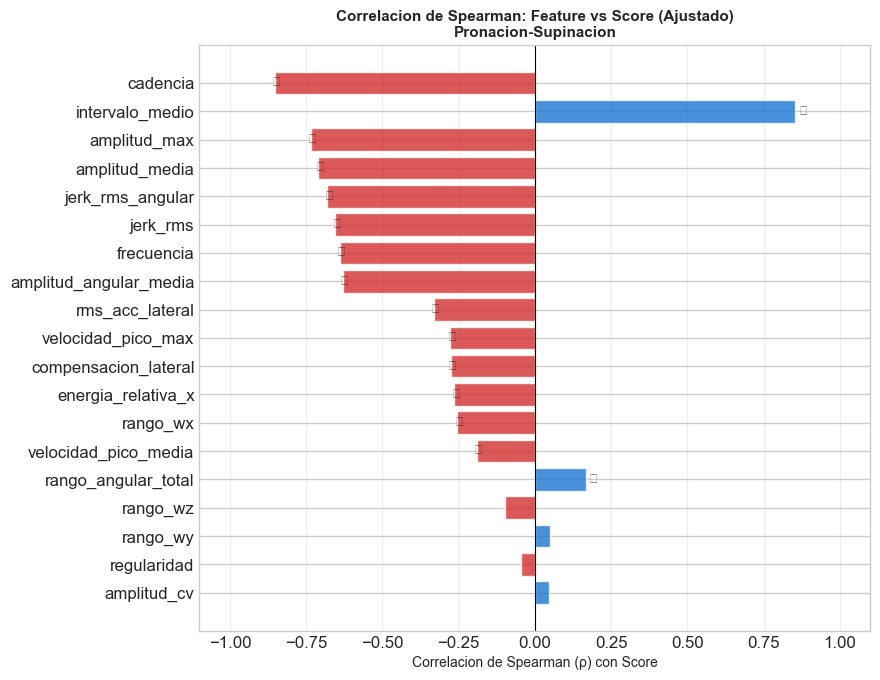

★ = p < 0.05

Top 5 correlaciones positivas (aumenta con severidad):
            feature      rho             p
    intervalo_medio 0.853468 3.730984e-112
rango_angular_total 0.167046  9.135790e-04
           rango_wy 0.048547  3.383458e-01
        amplitud_cv 0.045878  3.655930e-01

Top 5 correlaciones negativas (disminuye con severidad):
         feature       rho             p
        cadencia -0.853468 3.730984e-112
    amplitud_max -0.734490  1.747900e-67
  amplitud_media -0.709717  3.777421e-61
jerk_rms_angular -0.680355  1.866487e-54
        jerk_rms -0.653703  5.041399e-49

💾 Correlaciones guardadas


In [33]:
"""
============================================================================
CORRELACION DE SPEARMAN — Feature vs Score (AJUSTADO)
Muestra direccion e intensidad de la relacion con la severidad.
============================================================================
"""

if 'df_ajustado' not in globals():
    print("⚠️  Ejecuta primero la celda del LDA ajustado.")
else:
    corr_rows = []
    for feat in Config.FEATURES_ANALISIS:
        vals     = df_ajustado[feat].dropna()
        scores_v = df_ajustado.loc[vals.index, 'score']
        if len(vals) > 5:
            rho, p = spearmanr(vals, scores_v)
            corr_rows.append({'feature': feat, 'rho': rho, 'p': p, 'abs_rho': abs(rho)})

    df_corr = pd.DataFrame(corr_rows).sort_values('abs_rho', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 7))
    colores = ['#D32F2F' if r < 0 else '#1976D2' for r in df_corr['rho']]
    ax.barh(df_corr['feature'][::-1], df_corr['rho'][::-1],
            color=colores[::-1], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlacion de Spearman (ρ) con Score', fontsize=10)
    ax.set_title('Correlacion de Spearman: Feature vs Score (Ajustado)\nPronacion-Supinacion',
                 fontsize=11, fontweight='bold')

    for i, (_, row) in enumerate(df_corr[::-1].iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + 0.01*np.sign(row['rho']), i, '★',
                    fontsize=9, va='center')

    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim([-1.1, 1.1])
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/correlacion_spearman.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print("★ = p < 0.05")
    print("\nTop 5 correlaciones positivas (aumenta con severidad):")
    print(df_corr[df_corr['rho']>0].head(5)[['feature','rho','p']].to_string(index=False))
    print("\nTop 5 correlaciones negativas (disminuye con severidad):")
    print(df_corr[df_corr['rho']<0].head(5)[['feature','rho','p']].to_string(index=False))

    df_corr.to_csv(f"{Config.RUTA_SALIDA}/tablas/correlacion_spearman.csv", index=False)
    print("\n💾 Correlaciones guardadas")

---
## CELDA 11 — Exportación final y resumen ejecutivo

In [34]:
"""
============================================================================
EXPORTACION FINAL — Excel con todas las tablas + resumen ejecutivo (AJUSTADO)
============================================================================
"""

timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/pronosupina_analisis_completo_{timestamp}.xlsx"

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:

    # Hoja 1: Dataset maestro (ajustado)
    df_ajustado.drop(columns=['eje_gyro_dom','eje_accel_dom'], errors='ignore').to_excel(
        writer, sheet_name='dataset_maestro', index=False)

    # Hoja 2: Descriptivo por score
    df_descriptivo.to_excel(writer, sheet_name='descriptivo_por_score', index=False)

    # Hoja 3: Kruskal-Wallis
    df_kw.to_excel(writer, sheet_name='kruskal_wallis', index=False)

    # Hoja 4: Post-hoc Mann-Whitney
    if len(df_posthoc) > 0:
        df_posthoc.to_excel(writer, sheet_name='posthoc_mannwhitney', index=False)

    # Hoja 5: Correlaciones Spearman (ajustado)
    df_corr.to_excel(writer, sheet_name='correlacion_spearman', index=False)

    # Hoja 6: Predicciones LOSO (ajustado)
    if len(y_true_adj) > 0:
        pd.DataFrame({'y_real': y_true_adj, 'y_pred': y_pred_adj}).to_excel(
            writer, sheet_name='predicciones_loso', index=False)

    # Hoja 7: AUC por score (ajustado)
    if 'auc_por_score_adj' in dir() and len(auc_por_score_adj) > 0:
        df_auc = pd.DataFrame([
            {'score': s, 'auc_ovr': a,
             'interpretacion': ('excelente' if a>=0.9 else 'bueno' if a>=0.8
                                else 'aceptable' if a>=0.7 else 'bajo')}
            for s, a in auc_por_score_adj.items()
        ])
        if auc_macro_adj:    df_auc['auc_macro']    = auc_macro_adj
        if auc_weighted_adj: df_auc['auc_weighted'] = auc_weighted_adj
        df_auc.to_excel(writer, sheet_name='auc_resultados', index=False)

    # Hoja 8: Importancia features (ajustado)
    try:
        pd.DataFrame({'feature': features_ord_adj, 'importancia_l2': import_ord_adj}).to_excel(
            writer, sheet_name='importancia_features', index=False)
    except Exception:
        pass

print(f"✅ Excel exportado: {excel_path}")

# ── Resumen ejecutivo ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("RESUMEN EJECUTIVO — PRONACION-SUPINACION MDS-UPDRS 3.6 (AJUSTADO)")
print("="*65)

print(f"\n📊 DATASET")
print(f"   Total pruebas validas : {len(df_ajustado)}")
for s in Config.SCORES:
    n = len(df_ajustado[df_ajustado['score']==s])
    print(f"   Score {s}              : {n} pruebas")

print(f"\n⚙️  CONFIGURACION DE SENAL")
print(f"   Senal deteccion  : gx (ωx) directo (NO angulo integrado)")
print(f"   GYRO_LOWCUT      : {Config.GYRO_LOWCUT} Hz")
print(f"   Ciclos min validos: {Config.CICLOS_MIN_VALIDOS}")
print(f"   Features          : {len(Config.FEATURES_ANALISIS)} (sin ITI/hesitaciones/decremento)")

print(f"\n📈 ANALISIS INFERENCIAL (Kruskal-Wallis)")
sig_nom  = df_kw[df_kw['sig_nominal']]
sig_bonf = df_kw[df_kw['sig_bonf']]
print(f"   Features con p<0.05 (nominal) : {len(sig_nom)}/{len(df_kw)}")
print(f"   Features con p<0.05 (Bonf.)   : {len(sig_bonf)}/{len(df_kw)}")
print(f"   Features con efecto grande    : {len(df_kw[df_kw['efecto']=='grande'])}")
print(f"   Limitacion declarada          : N=3 sujetos en Scores 1-4")
print(f"                                   Poder estadistico ~25%")

print(f"\n🎯 DISCRIMINABILIDAD (LDA LOSO — AJUSTADO)")
if len(y_true_adj) > 0:
    acc_global = np.mean(y_true_adj == y_pred_adj)
    print(f"   Accuracy global  : {acc_global:.3f} ({acc_global*100:.1f}%)")
    if auc_macro_adj:    print(f"   AUC macro (OvR)  : {auc_macro_adj:.4f}")
    if auc_weighted_adj: print(f"   AUC weighted     : {auc_weighted_adj:.4f}")
    print(f"   Validacion       : Leave-One-Subject-Out")
else:
    print("   ⚠️  Sin resultados — revisar datos")

print(f"\n🏆 TOP 5 FEATURES MAS DISCRIMINATIVAS (Kruskal-Wallis eta²)")
for i, feat in enumerate(df_kw.head(5)['feature'], 1):
    eta = df_kw[df_kw['feature']==feat]['eta2'].values[0]
    print(f"   {i}. {feat:<34} eta²={eta:.4f}")

print(f"\n📁 Resultados guardados en: {Config.RUTA_SALIDA}/")
print("="*65)

✅ Excel exportado: ./resultados_pronosupina_completo/pronosupina_analisis_completo_20260505_223223.xlsx

RESUMEN EJECUTIVO — PRONACION-SUPINACION MDS-UPDRS 3.6 (AJUSTADO)

📊 DATASET
   Total pruebas validas : 391
   Score 0              : 149 pruebas
   Score 1              : 59 pruebas
   Score 2              : 61 pruebas
   Score 3              : 62 pruebas
   Score 4              : 60 pruebas

⚙️  CONFIGURACION DE SENAL
   Senal deteccion  : gx (ωx) directo (NO angulo integrado)
   GYRO_LOWCUT      : 0.1 Hz
   Ciclos min validos: 10
   Features          : 19 (sin ITI/hesitaciones/decremento)

📈 ANALISIS INFERENCIAL (Kruskal-Wallis)
   Features con p<0.05 (nominal) : 19/19
   Features con p<0.05 (Bonf.)   : 18/19
   Features con efecto grande    : 13
   Limitacion declarada          : N=3 sujetos en Scores 1-4
                                   Poder estadistico ~25%

🎯 DISCRIMINABILIDAD (LDA LOSO — AJUSTADO)
   Accuracy global  : 0.760 (76.0%)
   AUC macro (OvR)  : 0.9238
   AUC wei

In [38]:
from joblib import dump

# Exporta scaler + LDA ajustado en un solo archivo con nombres de features
if 'scaler_full_adj' not in globals() or 'lda_full_adj' not in globals():
    print("⚠️  Ejecuta primero la celda de importancia de features (ajustado).")
else:
    bundle_path = f"{Config.RUTA_SALIDA}/lda_pronosupina_bundle_ajustado.joblib"
    feature_names = list(Config.FEATURES_ANALISIS)
    dump({
        "scaler": scaler_full_adj,
        "lda": lda_full_adj,
        "feature_names": feature_names
    }, bundle_path)
    print(f"✅ Modelo ajustado exportado en: {bundle_path}")

✅ Modelo ajustado exportado en: ./resultados_pronosupina_completo/lda_pronosupina_bundle_ajustado.joblib
